# Supervisor follow-up, Friday

Four items raised on Thursday.

| # | raised by | item |
|---|---|---|
| 1 | Mauricio | Is class specificity destroyed, or relocated into the hotspot |
| 2 | Shelley | Diff-CAM normalisation may be dominated by background |
| 3 | both | Per-label case studies, which structure does the heat land on |
| 4 | Mauricio | Push alignment to failure, report F1 as well as AUC |

Section 1 below.

**The challenge.** At alpha=0 the two class maps differ but are dispersed and
score at chance against the annotations. At alpha=5 they look alike. Mauricio's
alternative reading is that the information is now contained inside the
hotspot, so the map has become specific to where it should be rather than
losing class specificity.

**The test.** The current correlation uses all 196 patches. Most are empty
background where both maps sit near zero, which inflates agreement.
Restricting to lesion patches removes that. If the maps still correlate at
0.97 inside the lesion, the objection does not hold. If the correlation
drops, it does.

In [1]:
# =============================================================================
# Setup. Self contained, duplicated from notebook 14 so this runs alone.
# =============================================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import cv2
import torch
import torchvision.transforms as T
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import spearmanr, wilcoxon


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.eval.cam_eval_utils import (
    mask_to_cam_grid_geom, transform_mask, transform_rgb,
    norm01, CAM_GRID, CROP_SIZE)

from run_class_finetuning_ha import (
    build_attention_gradcam_map, _unwrap_model, unpack_model_outputs,
    remap_norm_keys_for_pooling)
from scripts.generate_finer_cam_panderm import (
    build_panderm_model, remap_official_finetune_checkpoint_keys,
    extract_checkpoint_state_dict, infer_panderm_variant_from_state_dict,
    infer_checkpoint_pooling)

# ---- switches -------------------------------------------------------------
GEOMETRY = "squash224"
POOLING  = "mean"
POOL_TAG = "gap" if POOLING == "mean" else "cls"
BLOCK    = -1
TOP_K    = 20
MEL_IDX, NV_IDX = 0, 1
ALPHAS   = ["ha0", "ha3", "ha5"]
AV       = {"ha0": 0, "ha3": 3, "ha5": 5}

HAM_ROOT  = REPO / "data" / "HAM10000"
CKPT_DIR  = REPO / "external" / "checkpoints5"
EVAL_ROOT = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
OUT       = REPO / "results" / "followup" / POOL_TAG/ GEOMETRY
OUT.mkdir(parents=True, exist_ok=True)

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

C_ATTN, C_ACT, C_MEL = "#1F77B4", "#7F3F98", "#C62828"
mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300,
                     "savefig.bbox": "tight", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

PREPROCESS = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_df = pd.read_csv(EVAL_ROOT / "eval_images.csv")
qcp     = pd.read_csv(QC_CSV).query("qc_pass")
pred    = pd.read_csv(EVAL_ROOT / "predictions.csv")

_cache = {}


def load_model(ck):
    key = (POOL_TAG, ck)
    if key in _cache:
        return _cache[key]
    p = CKPT_DIR / f"checkpoint-best-{POOL_TAG}-{ck}.pth"
    obj = torch.load(p, map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)

    got = infer_checkpoint_pooling(obj, raw)
    if got is not None and got != POOLING:
        raise RuntimeError(f"{ck}: checkpoint pooling {got}, expected {POOLING}")

    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    st = remap_norm_keys_for_pooling(st, m)          # <-- the fix

    miss, unexp = m.load_state_dict(st, strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    if bad:
        raise RuntimeError(f"{ck}: critical keys {bad}")
    m.to(DEVICE).eval()
    for q in m.parameters():
        q.requires_grad_(True)
    _cache[key] = m
    return m


def load_tensor(rel):
    img = Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB")
    return PREPROCESS(img).unsqueeze(0).to(DEVICE)


def class_cams(model, x):
    """Both class attention CAMs from one forward. 14x14 each."""
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        out = model(x, return_patch_tokens=True, store_attn=True,
                    attn_layer=BLOCK)
        logits, _ = unpack_model_outputs(out)
        cams = []
        for idx in (MEL_IDX, NV_IDX):
            t = torch.full((1,), idx, device=logits.device, dtype=torch.long)
            cams.append(build_attention_gradcam_map(
                model, logits, t, create_graph=False).detach())
    base.clear_xai_state()
    g = lambda c: c[0].float().cpu().numpy()
    return g(cams[0]), g(cams[1])


def topk_mask(cam, k):
    f = np.asarray(cam, np.float32).ravel()
    k = max(1, min(int(k), f.size))
    o = np.zeros(f.size, bool)
    o[np.argpartition(-f, k - 1)[:k]] = True
    return o.reshape(cam.shape)


# lesion masks at grid resolution
LESION = {}
for _, r in eval_df.iterrows():
    m = np.array(Image.open((HAM_ROOT / str(r.mask_rel_path)).resolve())
                 .convert("L")) > 127
    LESION[r.image_id] = mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5

la = pd.Series({k: v.mean() for k, v in LESION.items()})
print(f"geometry {GEOMETRY}   pooling {POOL_TAG}   device {DEVICE}")
print(f"images {len(eval_df)}")
print(f"lesion coverage at {CAM_GRID}x{CAM_GRID}: "
      f"median {la.median():.3f}, range {la.min():.3f} to {la.max():.3f}")

geometry squash224   pooling gap   device mps
images 34
lesion coverage at 14x14: median 0.250, range 0.056 to 0.658


In [2]:
# =============================================================================
# SECTION 1. Is class specificity destroyed, or relocated inside the hotspot.
#
#   global       correlation over all patches
#   in-lesion    correlation over lesion patches only
#   nv_hot_lift  mean NV value inside the MEL top-k, divided by mean NV
#                elsewhere. Conditions on ONE map, so no collider bias.
#                1.0 means NV is indifferent to where MEL fires.
# =============================================================================
def mel_hot_stats(nm, nn, k, les):
    """Global lift, plus the lesion restricted version.
    Conditions on the MEL map only, so no collider bias."""
    sel = topk_mask(nm, k)
    r = (float(np.corrcoef(nm[sel], nn[sel])[0, 1])
         if sel.sum() >= 8 and nm[sel].std() > 1e-8 and nn[sel].std() > 1e-8
         else np.nan)
    lift_g = float(nn[sel].mean() / (nn[~sel].mean() + 1e-8)) if (~sel).any() else np.nan

    lift_l = np.nan
    n_in = int(les.sum())
    if n_in >= 8:
        a_in, b_in = nm[les], nn[les]
        k_in = max(2, int(round(0.10 * n_in)))
        s = np.zeros(n_in, bool)
        s[np.argpartition(-a_in, k_in - 1)[:k_in]] = True
        if (~s).any() and b_in[~s].mean() > 1e-8:
            lift_l = float(b_in[s].mean() / b_in[~s].mean())
    return r, lift_g, lift_l

rows = []
for ck in ALPHAS:
    mdl = load_model(ck)
    for _, r in eval_df.iterrows():
        cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
        les = LESION[r.image_id]
        nm, nn = norm01(cm), norm01(cn)

        g_r = float(np.corrcoef(nm.ravel(), nn.ravel())[0, 1])
        ma, mb = topk_mask(nm, TOP_K), topk_mask(nn, TOP_K)
        g_iou = float((ma & mb).sum() / ((ma | mb).sum() + 1e-8))
        h_r, h_lift, h_lift_les = mel_hot_stats(nm, nn, TOP_K, les)

        n_in = int(les.sum())
        if n_in >= 8:
            a_in, b_in = nm[les], nn[les]
            l_r = (float(np.corrcoef(a_in, b_in)[0, 1])
                   if a_in.std() > 1e-8 and b_in.std() > 1e-8 else np.nan)
            k_in = max(2, int(round(0.10 * n_in)))
            sa = np.zeros(n_in, bool); sa[np.argpartition(-a_in, k_in - 1)[:k_in]] = True
            sb = np.zeros(n_in, bool); sb[np.argpartition(-b_in, k_in - 1)[:k_in]] = True
            l_iou = float((sa & sb).sum() / ((sa | sb).sum() + 1e-8))
        else:
            l_r, l_iou, k_in = np.nan, np.nan, 0

        rows.append({
            "ckpt": ck, "alpha": AV[ck], "image_id": r.image_id,
            "gt_label": r.gt_label,
            "r_global": g_r, "r_lesion": l_r,
            "nv_hot_lift": h_lift, "nv_hot_lift_lesion": h_lift_les,
            "iou_global": g_iou, "iou_lesion": l_iou,
            "lesion_patches": n_in, "k_in_lesion": k_in,
            "mass_in_lesion_mel": float(nm[les].sum() / (nm.sum() + 1e-8)),
            "mass_in_lesion_nv":  float(nn[les].sum() / (nn.sum() + 1e-8)),
            "lesion_area_frac": float(les.mean()),
            "mass_ratio_mel_nv": float((nm[les].sum() / (nm.sum() + 1e-8))
                                       / (nn[les].sum() / (nn.sum() + 1e-8) + 1e-8)),
        })
    print(f"  done {ck}")

S1 = pd.DataFrame(rows)
S1["pooling"] = POOL_TAG

print("\n" + "=" * 82)
print("SECTION 1  class map correlation, three scopes")
print("=" * 82)
print(S1.groupby("ckpt")[["r_global", "r_lesion",
                          "nv_hot_lift", "nv_hot_lift_lesion",
                          "iou_global", "iou_lesion",
                          "mass_in_lesion_mel", "mass_in_lesion_nv"]]
      .median().reindex(ALPHAS).round(3).to_string())

print(S1.groupby("ckpt")[["nv_hot_lift", "nv_hot_lift_lesion"]]
      .median().round(6).to_string())
dead = S1[(S1.ckpt == "ha0") & S1.r_lesion.isna()].image_id.tolist()
print(f"\n{len(dead)} of {S1.image_id.nunique()} images have at least one "
      f"class map constant inside the lesion at alpha 0")
for iid in dead:
    cm, cn = class_cams(load_model("ha0"), load_tensor(
        eval_df.set_index("image_id").loc[iid].image_rel_path))
    L = LESION[iid]
    print(f"  {iid}   MEL max in lesion {norm01(cm)[L].max():.2e}   "
          f"NV max in lesion {norm01(cn)[L].max():.2e}")

print("\nchange from alpha 0 to alpha 5")
for col, nm_ in [("r_global", "correlation, all patches"),
                 ("r_lesion", "correlation, in lesion"),
                 ("nv_hot_lift", "NV lift in MEL hotspot, global"),
                 ("nv_hot_lift_lesion", "NV lift in MEL hotspot, in lesion"),
                 ("mass_in_lesion_mel", "CAM mass inside lesion")]:
    pr = (S1.pivot_table(index="image_id", columns="ckpt", values=col)
            .reindex(columns=["ha0", "ha5"]).dropna())
    if len(pr) < 5:
        continue
    _, p = wilcoxon(pr.ha5, pr.ha0)
    print(f"  {nm_:28} {pr.ha0.median():+.3f} -> {pr.ha5.median():+.3f}"
          f"   diff {(pr.ha5 - pr.ha0).median():+.3f}   p {p:.2e}   n {len(pr)}")

print("\n" + "-" * 82)
pr = (S1.pivot_table(index="image_id", columns="ckpt", values="r_lesion")
        .reindex(columns=["ha0", "ha5"]).dropna())
lr5, n_pair = pr.ha5.median(), len(pr)
gr5 = S1[S1.ckpt == "ha5"].r_global.median()
if lr5 > 0.85:
    print(f"VERDICT. The maps remain near identical INSIDE the lesion")
    print(f"        (r = {lr5:.3f} versus {gr5:.3f} globally, n = {n_pair}).")
    print(f"        The collapse is not an artifact of background agreement.")
elif lr5 < 0.5:
    print(f"VERDICT. The maps DO differ inside the lesion")
    print(f"        (r = {lr5:.3f} versus {gr5:.3f} globally, n = {n_pair}).")
    print(f"        Mauricio is right. Restate the E4 claim.")
else:
    print(f"VERDICT. Partial. In lesion r = {lr5:.3f} versus {gr5:.3f} global,")
    print(f"        n = {n_pair}. Weak class signal survives.")

  done ha0
  done ha3
  done ha5

SECTION 1  class map correlation, three scopes
      r_global  r_lesion  nv_hot_lift  nv_hot_lift_lesion  iou_global  iou_lesion  mass_in_lesion_mel  mass_in_lesion_nv
ckpt                                                                                                                    
ha0     -0.241    -0.327        0.060               0.000       0.000       0.000               0.517              0.205
ha3      0.969     0.858        5.372               1.173       0.538       0.261               0.838              0.871
ha5      0.970     0.900        5.367               1.132       0.455       0.200               0.851              0.879
      nv_hot_lift  nv_hot_lift_lesion
ckpt                                 
ha0      0.059735            0.000000
ha3      5.371989            1.172697
ha5      5.367235            1.132290

2 of 34 images have at least one class map constant inside the lesion at alpha 0
  ISIC_0026706   MEL max in lesion 5.44e-0

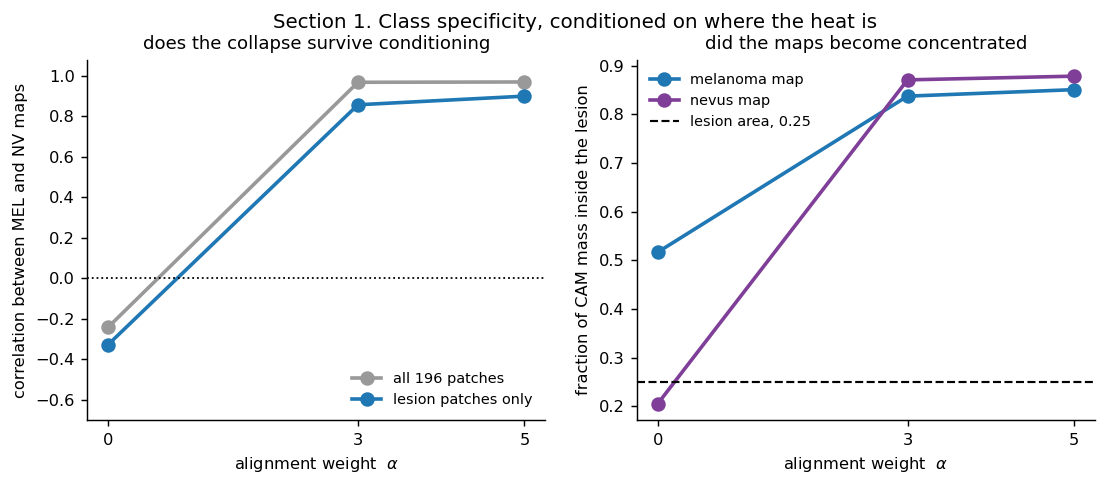

In [3]:
# =============================================================================
# FIGURE. Left, does the collapse survive conditioning. Right, concentration.
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
XT = [AV[c] for c in ALPHAS]

for col, col_c, nm_ in [("r_global", "#999999", f"all {CAM_GRID ** 2} patches"),
                        ("r_lesion", C_ATTN, "lesion patches only")]:
    ax[0].plot(XT, S1.groupby("ckpt")[col].median().reindex(ALPHAS).values,
               "o-", color=col_c, lw=2, ms=7, label=nm_)
ax[0].axhline(0, color="k", ls=":", lw=1)
ax[0].set_xticks(XT)
ax[0].set_xlabel(r"alignment weight  $\alpha$")
ax[0].set_ylabel("correlation between MEL and NV maps")
ax[0].set_ylim(-0.7, 1.08)
ax[0].legend(frameon=False, fontsize=8, loc="lower right")
ax[0].set_title("does the collapse survive conditioning", fontsize=10)

for col, col_c, nm_ in [("mass_in_lesion_mel", C_ATTN, "melanoma map"),
                        ("mass_in_lesion_nv", C_ACT, "nevus map")]:
    ax[1].plot(XT, S1.groupby("ckpt")[col].median().reindex(ALPHAS).values,
               "o-", color=col_c, lw=2, ms=7, label=nm_)
la_med = S1.lesion_area_frac.median()
ax[1].axhline(la_med, color="k", ls="--", lw=1.2,
              label=f"lesion area, {la_med:.2f}")
ax[1].set_xticks(XT)
ax[1].set_xlabel(r"alignment weight  $\alpha$")
ax[1].set_ylabel("fraction of CAM mass inside the lesion")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("did the maps become concentrated", fontsize=10)

fig.suptitle("Section 1. Class specificity, conditioned on where the heat is",
             fontsize=11)
fig.savefig(OUT / "s1_conditioned_correlation.png")
plt.show()

In [4]:
# =============================================================================
# SECTION 1b. Paired tests, IoU against chance, Spearman, concentration.
# =============================================================================
def paired(df, col, a, b):
    p = (df.pivot_table(index="image_id", columns="ckpt", values=col)
           .reindex(columns=[a, b]).dropna())
    if len(p) < 5:
        return None
    d = (p[a] - p[b]).to_numpy()
    if not np.any(d != 0):
        return {"n": len(p), "diff": 0.0, "p": 1.0, "wins": 0, "losses": 0}
    _, pv = wilcoxon(p[a], p[b])
    return {"n": len(p), "diff": float(np.median(d)), "p": float(pv),
            "wins": int((d > 0).sum()), "losses": int((d < 0).sum())}

print("=" * 78)
print("1. PAIRED TESTS, alpha 5 versus alpha 0")
print("=" * 78)
for col, nm_ in [("r_global", "correlation, all patches"),
                 ("r_lesion", "correlation, in lesion"),
                 ("nv_hot_lift", "NV lift in MEL hotspot, global"),
                 ("nv_hot_lift_lesion", "NV lift in MEL hotspot, in lesion"),
                 ("iou_global", "top-k overlap, all patches"),
                 ("iou_lesion", "top-k overlap, in lesion"),
                 ("mass_in_lesion_mel", "MEL mass inside lesion"),
                 ("mass_in_lesion_nv", "NV mass inside lesion")]:
    r = paired(S1, col, "ha5", "ha0")
    if r:
        print(f"  {nm_:30} {r['diff']:+.3f}   p {r['p']:.2e}   "
              f"n {r['n']}   ({r['wins']}/{r['losses']})")

print("\n" + "=" * 78)
print("2. IOU AGAINST CHANCE")
print("=" * 78)
print("  expected IoU for two random sets of size k drawn from n is k/(2n-k)")
print("  in lesion k is 10 percent of the lesion, matching the global ratio,")
print("  so the two chance values coincide by construction")
ch_g = TOP_K / (2 * CAM_GRID ** 2 - TOP_K)
kl = S1[S1.k_in_lesion > 0].k_in_lesion.median()
nl = S1[S1.k_in_lesion > 0].lesion_patches.median()
ch_l = kl / (2 * nl - kl)
print(f"\n  global     k={TOP_K}  n={CAM_GRID ** 2}   chance {ch_g:.3f}")
print(f"  in lesion  k={kl:.0f}   n={nl:.0f}    chance {ch_l:.3f}")
print(f"\n  {'':10} {'observed':>10} {'chance':>8} {'lift':>8}")
for ck in ALPHAS:
    g = S1[S1.ckpt == ck].iou_global.median()
    l = S1[S1.ckpt == ck].iou_lesion.median()
    print(f"  {ck:10} {g:10.3f} {ch_g:8.3f} {g / ch_g:7.1f}x   global")
    print(f"  {'':10} {l:10.3f} {ch_l:8.3f} {l / ch_l:7.1f}x   in lesion")

print("\n" + "=" * 78)
print("3. SPEARMAN INSIDE THE LESION")
print("=" * 78)
print("  rank based, resists the range restriction that compresses Pearson")
rows = []
for ck in ALPHAS:
    mdl = load_model(ck)
    for _, r in eval_df.iterrows():
        les = LESION[r.image_id]
        if les.sum() < 8:
            continue
        cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
        a, b = norm01(cm)[les], norm01(cn)[les]
        sp = (float(spearmanr(a, b).statistic)
              if a.std() > 1e-8 and b.std() > 1e-8 else np.nan)
        rows.append({"ckpt": ck, "image_id": r.image_id, "spearman_lesion": sp})
SP = pd.DataFrame(rows)
print()
print(SP.groupby("ckpt").spearman_lesion
      .agg(n="count", median="median").reindex(ALPHAS).round(3).to_string())

print("\n" + "=" * 78)
print("4. CONCENTRATION AGAINST THE LESION AREA")
print("=" * 78)
print("  mass below the lesion area fraction means the map prefers background")
print("  p_bonf corrects for the six tests in this block")
tests = []
for ck in ALPHAS:
    s = S1[S1.ckpt == ck]
    for col, nm_ in [("mass_in_lesion_mel", "MEL"),
                     ("mass_in_lesion_nv", " NV")]:
        _, pv = wilcoxon(s[col], s.lesion_area_frac)
        tests.append({"ckpt": ck, "map": nm_, "mass": s[col].median(),
                      "area": s.lesion_area_frac.median(),
                      "diff": (s[col] - s.lesion_area_frac).median(), "p": pv})
TB = pd.DataFrame(tests)
TB["p_bonf"] = (TB.p * len(TB)).clip(upper=1.0)
for _, t in TB.iterrows():
    print(f"  {t.ckpt}  {t['map']}  mass {t.mass:.3f}  area {t.area:.3f}  "
          f"diff {t['diff']:+.3f}  p {t.p:.2e}  p_bonf {t.p_bonf:.2e}  "
          f"{'BELOW' if t['diff'] < 0 else 'above'} chance, "
          f"{'sig' if t.p_bonf < 0.05 else 'n.s. corrected'}")

S1.merge(SP, on=["ckpt", "image_id"], how="left") \
  .to_csv(OUT / "s1_conditioned_class_correlation.csv", index=False)

print("\n" + "-" * 78)
n0, n5 = S1[S1.ckpt == "ha0"], S1[S1.ckpt == "ha5"]
area = n0.lesion_area_frac.median()
mel0, nv0 = n0.mass_in_lesion_mel.median(), n0.mass_in_lesion_nv.median()
rel = lambda m: "below chance" if m < area else f"{m / area:.1f}x chance"
lo_row = TB[(TB.ckpt == "ha0") & (TB["diff"] < 0)]

print(f"""SYNTHESIS, {POOL_TAG.upper()}
Lesion covers {area:.3f} of the grid.
At alpha=0
  MEL map  {mel0:.3f} of its mass inside the lesion, {rel(mel0)}
  NV  map  {nv0:.3f} of its mass inside the lesion, {rel(nv0)}
  correlation in lesion {n0.r_lesion.median():+.3f}""")
print(f"""  MEL to NV mass ratio, median of per image ratios: {n0.mass_ratio_mel_nv.median():.2f}
  the ratio of the two medians above is {mel0 / nv0:.2f}, they differ because
  the median of ratios is not the ratio of medians""")

if len(lo_row):
    t = lo_row.iloc[0]
    qual = "" if t.p_bonf < 0.05 else " (not significant after correction, "\
                                     "so read this as at or below chance)"
    print(f"""
  The {t['map'].strip()} map sits below chance on the lesion{qual}.
  The anti correlation is one map on the lesion and one on background,
  not two competing hypotheses about the lesion.""")
else:
    print(f"""
  Both maps are above chance on the lesion and they are anti correlated.
  This is closer to two competing hypotheses about the same region.""")

print(f"""
At alpha=5
  MEL {n5.mass_in_lesion_mel.median():.3f}   NV {n5.mass_in_lesion_nv.median():.3f}
  correlation in lesion {n5.r_lesion.median():+.3f}
  NV lift in MEL hotspot, global {n5.nv_hot_lift.median():.2f}, was {n0.nv_hot_lift.median():.2f}
  NV lift in MEL hotspot, in lesion {n5.nv_hot_lift_lesion.median():.2f}, was {n0.nv_hot_lift_lesion.median():.2f}
  peak agreement {n5.iou_lesion.median() / ch_l:.1f}x chance in lesion
                 {n5.iou_global.median() / ch_g:.1f}x chance globally""")

1. PAIRED TESTS, alpha 5 versus alpha 0
  correlation, all patches       +1.195   p 1.16e-10   n 34   (34/0)
  correlation, in lesion         +1.189   p 4.66e-10   n 32   (32/0)
  NV lift in MEL hotspot, global +5.159   p 1.16e-10   n 34   (34/0)
  NV lift in MEL hotspot, in lesion +1.110   p 4.66e-10   n 32   (32/0)
  top-k overlap, all patches     +0.429   p 3.53e-07   n 34   (34/0)
  top-k overlap, in lesion       +0.188   p 3.39e-05   n 34   (27/1)
  MEL mass inside lesion         +0.330   p 1.16e-10   n 34   (34/0)
  NV mass inside lesion          +0.687   p 1.16e-10   n 34   (34/0)

2. IOU AGAINST CHANCE
  expected IoU for two random sets of size k drawn from n is k/(2n-k)
  in lesion k is 10 percent of the lesion, matching the global ratio,
  so the two chance values coincide by construction

  global     k=20  n=196   chance 0.054
  in lesion  k=5   n=49    chance 0.054

               observed   chance     lift
  ha0             0.000    0.054     0.0x   global
               

In [5]:
for col in ["iou_global", "iou_lesion", "r_lesion"]:
    s = S1.groupby("ckpt")[col].median().reindex(ALPHAS)
    if s.ha5 < s.ha3:
        print(f"  NOTE {col}: ha5 {s.ha5:.3f} below ha3 {s.ha3:.3f}, "
              f"non-monotone, consistent with run to run variance in the "
              f"ha5 checkpoint")

  NOTE iou_global: ha5 0.455 below ha3 0.538, non-monotone, consistent with run to run variance in the ha5 checkpoint
  NOTE iou_lesion: ha5 0.200 below ha3 0.261, non-monotone, consistent with run to run variance in the ha5 checkpoint


In [6]:
z = (S1[S1.ckpt == "ha0"].nv_hot_lift_lesion == 0).mean()
print(f"  NV exactly zero at the MEL hotspot inside the lesion in "
      f"{z:.0%} of images at alpha 0")

  NV exactly zero at the MEL hotspot inside the lesion in 68% of images at alpha 0


---
## Section 2. Diff-CAM, renormalised inside the lesion

**Shelley's objection.** The difference may be genuinely inside the lesion,
but the global normalisation is dominated by activations outside it. Since
`diff = max(0, cam_A - cam_B)` is then divided by its global maximum, a
large off-lesion difference crushes the in-lesion signal toward zero.

**Her fix.** Restrict to the lesion first, then normalise.

**Three variants tested.**

| variant | procedure |
|---|---|
| global | current. difference over the whole grid, global max |
| lesion normalised | difference over the whole grid, renormalised on lesion patches |
| lesion restricted | both maps restricted to the lesion first, then differenced |

Each scored against the melanoma feature union, with a permutation null.

**Her caveat, recorded.** Annotations can legitimately fall outside the
lesion, for example vascular patterns. Masking is therefore a diagnostic
for whether the normalisation is the problem, not a universally correct
procedure.

**Scoring.** AUC is computed inside the lesion only. Scoring over the full
grid rewards the masked variants for information they did not have. A centre
of lesion distance map is included as an oracle floor.

In [ ]:
# =============================================================================
# SECTION 2. Is Diff-CAM at chance, or is the normalisation hiding the signal.
#
# CRITICAL. AUC is scored INSIDE THE LESION ONLY. Scoring over the full grid
# gives the masked variants a free advantage, because they are zero outside
# the lesion and the MEL union is inside it. That advantage comes from ground
# truth the map never had.
#
# Note the identity. v_global[les] and v_lesnorm[les] are both positive scalar
# multiples of d[les], so their in-lesion RANKING is identical and their
# in-lesion AUC must match exactly. Shelley's fix cannot change in-lesion
# ranking. Only lesion_restricted can.
# =============================================================================
from sklearn.metrics import roc_auc_score
from scipy.ndimage import center_of_mass

CK = "ha5"
mdl = load_model(CK)

def mel_union_grid(image_id):
    sub = qcp[(qcp.Image_ID == image_id) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return mask_to_cam_grid_geom(acc, GEOMETRY) >= 0.5

UNION = {i: mel_union_grid(i) for i in eval_df.image_id}

def diff_variants(cm, cn, les):
    a, b = norm01(cm), norm01(cn)
    d = np.clip(a - b, 0, None)
    v_global = d / (d.max() + 1e-8)
    v_lesnorm = np.zeros_like(d)
    if les.sum() >= 4 and d[les].max() > 1e-8:
        v_lesnorm[les] = d[les] / d[les].max()
    v_lesres = np.zeros_like(d)
    if les.sum() >= 4:
        ai, bi = a[les], b[les]
        ai = (ai - ai.min()) / (ai.max() - ai.min() + 1e-8)
        bi = (bi - bi.min()) / (bi.max() - bi.min() + 1e-8)
        di = np.clip(ai - bi, 0, None)
        v_lesres[les] = di / (di.max() + 1e-8)
    return {"global": v_global, "lesion_norm": v_lesnorm,
            "lesion_restricted": v_lesres}

def centre_map(les):
    cy, cx = center_of_mass(les.astype(float))
    yy, xx = np.mgrid[0:CAM_GRID, 0:CAM_GRID]
    return norm01(-np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2))

VARIANTS = ["global", "lesion_norm", "lesion_restricted"]
SCORED = ["gradcam_mel", "centre"] + VARIANTS

store, rows = {}, []
for _, r in eval_df.iterrows():
    un, les = UNION.get(r.image_id), LESION[r.image_id]
    if un is None or les.sum() < 8:
        continue
    ui = un[les]
    if ui.sum() == 0 or ui.all():          # need both classes INSIDE the lesion
        continue
    cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
    dv = diff_variants(cm, cn, les)
    maps = {"gradcam_mel": norm01(cm), "centre": centre_map(les), **dv}
    store[r.image_id] = {"un": un, "les": les, **maps}

    row = {"image_id": r.image_id, "gt_label": r.gt_label,
           "union_frac_of_lesion": float(ui.mean()),
           "lesion_patches": int(les.sum())}
    for k, v in maps.items():
        vi = v[les]
        row[k] = float(roc_auc_score(ui.astype(int), vi)) if vi.std() > 1e-8 else np.nan
    row["global_outside"] = float(dv["global"][~les].sum()
                                  / (dv["global"].sum() + 1e-8))
    rows.append(row)

S2 = pd.DataFrame(rows)

# the identity check. global and lesion_norm must agree inside the lesion
delta = (S2["global"] - S2.lesion_norm).abs().max()
print(f"identity check, max |global - lesion_norm| in lesion: {delta:.2e}")
assert delta < 1e-9, "in-lesion ranking should be identical by construction"

# ---- permutation null, all ordered pairs, in lesion of the DONOR image -----
ids = list(store)
null = {}
for k in SCORED:
    vals = []
    for i in range(len(ids)):
        for j in range(len(ids)):
            if i == j:
                continue
            L = store[ids[j]]["les"]
            ui = store[ids[j]]["un"][L]
            vi = store[ids[i]][k][L]
            if ui.sum() == 0 or ui.all() or vi.std() < 1e-8:
                continue
            vals.append(roc_auc_score(ui.astype(int), vi))
    null[k] = (float(np.mean(vals)), float(np.percentile(vals, 95)))

S2.to_csv(OUT / "s2_diffcam_variants.csv", index=False)

print("=" * 82)
print(f"SECTION 2  Diff-CAM in lesion, against the MEL union, n={len(S2)}")
print(f"union covers {S2.union_frac_of_lesion.median():.3f} of the lesion, "
      f"median {S2.lesion_patches.median():.0f} lesion patches")
print("=" * 82)
print(f"{'variant':26} {'AUC':>8} {'null':>8} {'above':>8} {'>p95':>6}")
print("-" * 82)
for k, nm_ in [("gradcam_mel", "Grad-CAM MEL, reference"),
               ("centre", "centre of lesion, oracle"),
               ("global", "Diff, global norm"),
               ("lesion_norm", "Diff, lesion norm"),
               ("lesion_restricted", "Diff, lesion restricted")]:
    obs = S2[k].median()
    mu, p95 = null[k]
    print(f"{nm_:26} {obs:8.3f} {mu:8.3f} {obs - mu:+8.3f} "
          f"{'yes' if obs > p95 else 'no':>6}")

print("\npaired, in lesion")
for a, b, nm_ in [("lesion_norm", "global", "lesion norm vs global"),
                  ("lesion_restricted", "global", "lesion restr vs global"),
                  ("global", "centre", "diff global vs centre"),
                  ("lesion_restricted", "centre", "diff restr vs centre"),
                  ("gradcam_mel", "centre", "Grad-CAM vs centre")]:
    p = S2[[a, b]].dropna()
    d = (p[a] - p[b]).to_numpy()
    if len(p) < 5 or not np.any(d != 0):
        print(f"  {nm_:26} identical, no test")
        continue
    _, pv = wilcoxon(p[a], p[b])
    print(f"  {nm_:26} {np.median(d):+.3f}   p {pv:.2e}   "
          f"({int((d > 0).sum())}/{int((d < 0).sum())})")

print(f"in-lesion ranking untouched. Any full-grid gain is the mask, not signal.")
best = max(VARIANTS, key=lambda k: abs(S2[k].median() - 0.5))
obs, mu, p95 = S2[best].median(), *null[best]
vs_c = S2[best].median() - S2.centre.median()
_, p_half = wilcoxon(S2[best] - 0.5)

print("\n" + "-" * 82)
print(f"Shelley's fix zeroes the mass outside the lesion "
      f"({S2.global_outside.median():.3f} to 0.000) but the identity check "
      f"confirms\nin-lesion ranking is untouched. Any full-grid gain was the "
      f"mask, not signal.")

if obs < 0.5 and p_half < 0.05:
    print(f"\nVERDICT. The difference map is INVERTED, not empty. '{best}' "
          f"scores {obs:.3f},\n        {0.5 - obs:.3f} below chance "
          f"(p {p_half:.2e}) and {mu - obs:.3f} below its permutation null\n"
          f"        of {mu:.3f}. Negating it gives {1 - obs:.3f}, comparable "
          f"to Grad-CAM at\n        {S2.gradcam_mel.median():.3f}. The "
          f"difference carries image specific information\n        that "
          f"systematically avoids the annotated melanoma features.")
elif obs > max(p95, S2.centre.median()):
    print(f"\nVERDICT. '{best}' reaches {obs:.3f}, clears p95 and beats the "
          f"centre oracle by {vs_c:+.3f}.")
else:
    print(f"\nVERDICT. '{best}' at {obs:.3f} is indistinguishable from its "
          f"null of {mu:.3f}\n        (p {p_half:.2e} against chance).")

identity check, max |global - lesion_norm| in lesion: 0.00e+00
SECTION 2  Diff-CAM in lesion, against the MEL union, n=31
union covers 0.680 of the lesion, median 50 lesion patches
variant                         AUC     null    above   >p95
----------------------------------------------------------------------------------
Grad-CAM MEL, reference       0.700    0.642   +0.058     no
centre of lesion, oracle      0.828    0.779   +0.049     no
Diff, global norm             0.276    0.492   -0.217     no
Diff, lesion norm             0.276    0.529   -0.254     no
Diff, lesion restricted       0.412    0.531   -0.119     no

paired, in lesion
  lesion norm vs global      identical, no test
  lesion restr vs global     +0.007   p 1.16e-03   (16/4)
  diff global vs centre      -0.507   p 1.86e-09   (1/30)
  diff restr vs centre       -0.428   p 1.86e-09   (1/30)
  Grad-CAM vs centre         -0.101   p 2.90e-03   (9/22)

----------------------------------------------------------------------

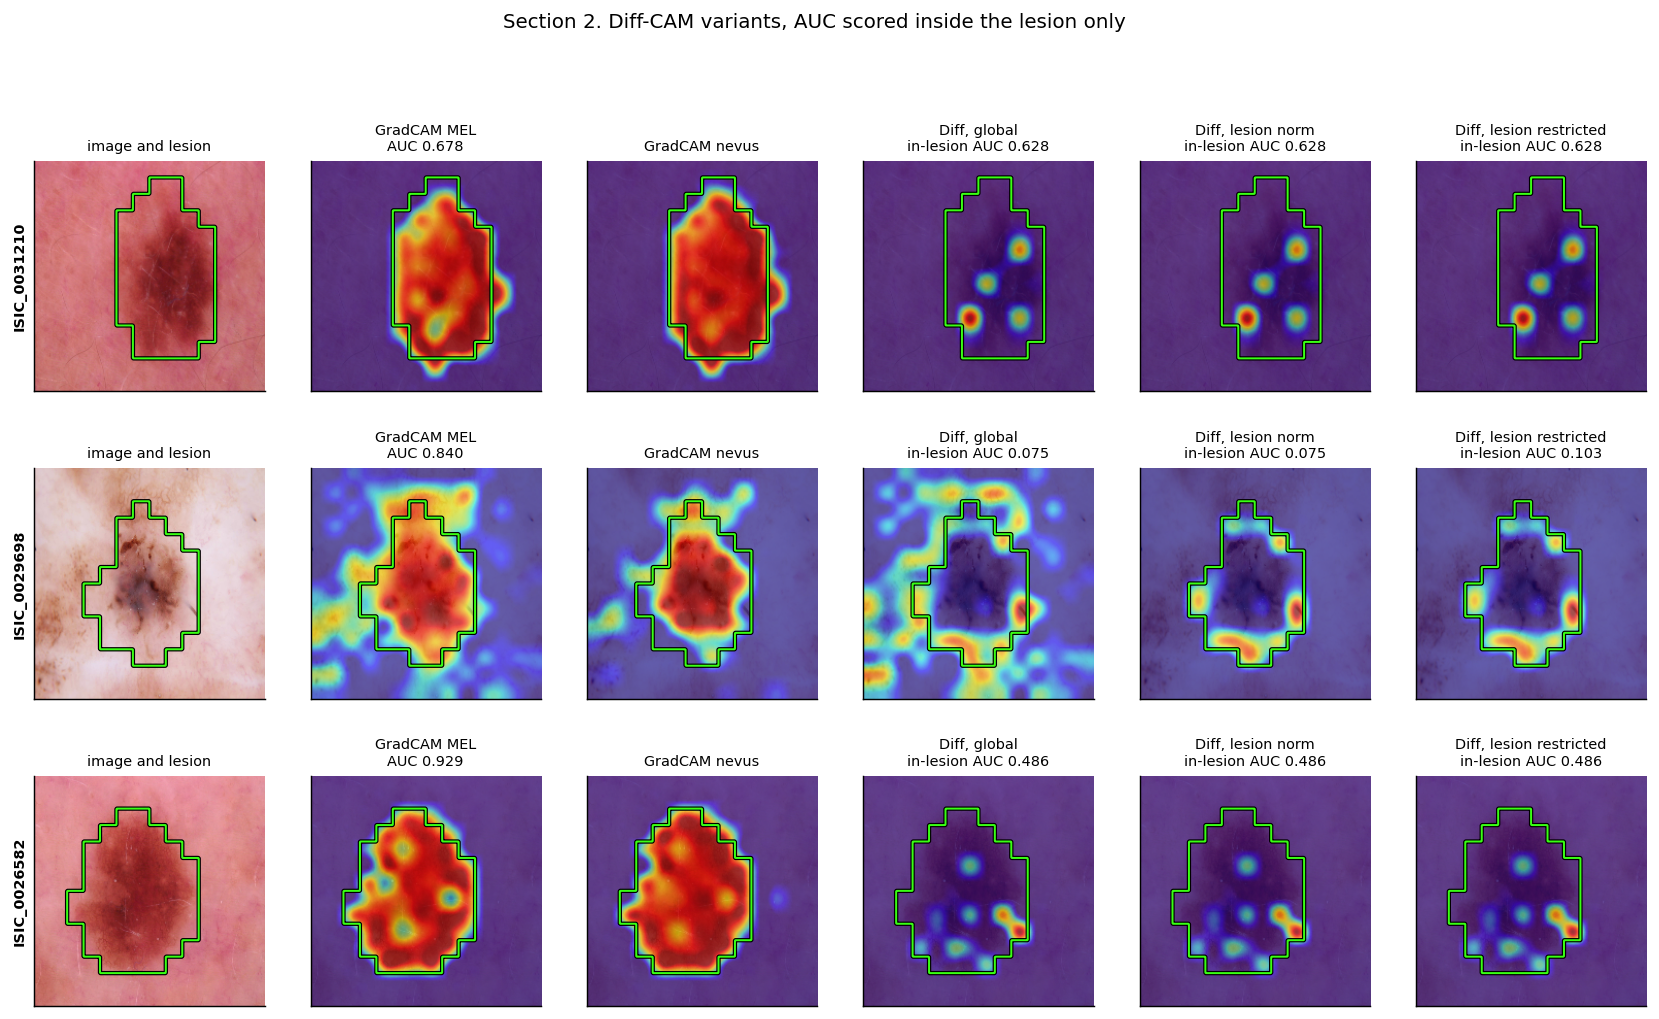

    image_id gt_label  gradcam_mel  centre  global  lesion_norm  lesion_restricted  global_outside  union_frac_of_lesion
ISIC_0024756      MEL        0.631   0.889   0.521        0.521              0.500           0.818                 0.791
ISIC_0024886      MEL        0.739   0.618   0.476        0.476              0.476           0.776                 0.423
ISIC_0024967      MEL        0.700   0.575   0.275        0.275              0.225           0.263                 0.976
ISIC_0025132      MEL        0.469   0.829   0.184        0.184              0.342           0.697                 0.680
ISIC_0025214       NV        0.700   0.704   0.324        0.324              0.324           0.655                 0.707
ISIC_0026491       NV        0.637   0.777   0.140        0.140              0.140           0.767                 0.364
ISIC_0026582       NV        0.929   0.709   0.486        0.486              0.486           0.000                 0.847
ISIC_0026584       NV        0.9

In [8]:
# =============================================================================
# FIGURE. Three cases. Best diff, worst diff, best Grad-CAM.
# =============================================================================
SHOW = list(dict.fromkeys(
    list(S2.nlargest(1, "lesion_restricted").image_id)
    + list(S2.nsmallest(1, "lesion_restricted").image_id)
    + list(S2.nlargest(1, "gradcam_mel").image_id)))[:3]

def draw(ax, rgb, les224, cam, title):
    ax.imshow(rgb)
    if cam is not None and cam.max() > 1e-8:
        ax.imshow(cv2.resize(norm01(cam), (CROP_SIZE, CROP_SIZE),
                             interpolation=cv2.INTER_CUBIC),
                  cmap="jet", alpha=0.58, vmin=0, vmax=1)
    ax.contour(les224, [0.5], colors="black", linewidths=2.4)
    ax.contour(les224, [0.5], colors="#39FF14", linewidths=1.1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=8)

fig, axes = plt.subplots(len(SHOW), 6, figsize=(16, 2.9 * len(SHOW)))
axes = np.atleast_2d(axes)
for i, iid in enumerate(SHOW):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(np.array(Image.open(
        (HAM_ROOT / str(r.image_rel_path)).resolve()).convert("RGB")), GEOMETRY)
    cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
    les = LESION[iid]
    dv = diff_variants(cm, cn, les)
    les224 = cv2.resize(les.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                        interpolation=cv2.INTER_NEAREST)
    row = S2[S2.image_id == iid].iloc[0]
    draw(axes[i, 0], rgb, les224, None, "image and lesion")
    draw(axes[i, 1], rgb, les224, cm, f"GradCAM MEL\nAUC {row.gradcam_mel:.3f}")
    draw(axes[i, 2], rgb, les224, cn, "GradCAM nevus")
    for j, k in enumerate(VARIANTS, start=3):
        draw(axes[i, j], rgb, les224, dv[k],
             f"Diff, {k.replace('_', ' ')}\nin-lesion AUC {row[k]:.3f}")
    axes[i, 0].set_ylabel(iid, fontsize=8, fontweight="bold")

fig.suptitle("Section 2. Diff-CAM variants, AUC scored inside the lesion only",
             fontsize=11, y=1.00)
fig.savefig(OUT / "s2_diffcam_variants.png")
plt.show()

print(S2[["image_id", "gt_label", "gradcam_mel", "centre"] + VARIANTS
         + ["global_outside", "union_frac_of_lesion"]]
      .round(3).to_string(index=False))

In [9]:
from scipy.ndimage import distance_transform_edt

rows = []
for iid, s in store.items():
    L, u = s["les"], s["un"]
    dist = distance_transform_edt(L)                 # 0 at rim, large at core
    dn = dist[L] / (dist[L].max() + 1e-8)
    a, b = s["gradcam_mel"], None
    for k in VARIANTS:
        v = s[k][L]
        if v.std() < 1e-8:
            continue
        rows.append({"image_id": iid, "variant": k,
                     "r_depth": float(spearmanr(v, dn).statistic)})
    rows.append({"image_id": iid, "variant": "gradcam_mel",
                 "r_depth": float(spearmanr(s["gradcam_mel"][L], dn).statistic)})
    rows.append({"image_id": iid, "variant": "MEL_union",
                 "r_depth": float(spearmanr(u[L].astype(float), dn).statistic)})
    rows.append({"image_id": iid, "variant": "saturated_frac",
                 "r_depth": float(((s["gradcam_mel"][L] > 0.9)).mean())})

D = pd.DataFrame(rows)
print("\n" + "=" * 82)
print("MECHANISM. Depth inside the lesion, rank correlation with distance to rim")
print("  positive means the map prefers the core, negative means the rim")
print("=" * 82)
print(D.groupby("variant").r_depth.median().round(3).to_string())


MECHANISM. Depth inside the lesion, rank correlation with distance to rim
  positive means the map prefers the core, negative means the rim
variant
MEL_union            0.470
global              -0.097
gradcam_mel          0.189
lesion_norm         -0.097
lesion_restricted   -0.074
saturated_frac       0.410


---
## Section 3. Which structure does the heat land on

**The request.** On images carrying several distinct labels, which one does
the heat actually select. Not group level, label level.

**Two questions per image.**

| question | metric |
|---|---|
| did the model reach this structure | coverage, corrected for size |
| where did the heat actually go | share of top-k mass per label |

The second is the one they asked for. It attributes the heat across the
labels present, so the shares sum to at most one.

**Caveat.** Labels overlap spatially, so shares are not exclusive. Share is
also confounded by label size, so the ranking is reported by enrichment over
a within-lesion shuffle null rather than by raw share.

**CAM family.** This section uses precomputed activation CAMs. Sections 1 and
2 use attention CAMs. The two are not comparable.

In [ ]:
# =============================================================================
# SECTION 3. Heat attribution across labels, per image.
#
# CAM FAMILY. Precomputed ACTIVATION CAMs from act__{ckpt}__g0p6. Sections 1
# and 2 use attention CAMs computed live. Not comparable across sections.
#
# NULL. Share is confounded by label size, and a global chance rate is wrong
# because the heat sits inside the lesion. The null shuffles CAM values across
# lesion patches only, preserving the value distribution and the lesion
# confinement, destroying only which structure the heat selected.
#   excess     = observed share minus null share.   PRIMARY.
#   enrichment = observed / null. Unstable for small labels, secondary.
#
# CONTROL. Built at ha0 as well as at CK. Finer-CAM depends on the class
# difference, which Section 2 showed is degenerate at high alpha, so the
# Grad-CAM comparison is only meaningful where the classes still differ.
# =============================================================================
CAM_TYPES = {"gradcam_a": "Grad-CAM", "finercam": "Finer-CAM"}
ACT_DIR = EVAL_ROOT / f"act__{CK}__g0p6"      # figures only
N_PERM = 200
MIN_N = 3
labs = sorted(qcp.label.unique())
PAL = {l: plt.cm.tab20(i / 20) for i, l in enumerate(labs)}

def load_act(image_id, kind, act_dir=None):
    f = (act_dir or ACT_DIR) / "raw_cams" / f"{image_id}_{kind}.npy"
    if not f.exists():
        return None
    a = np.load(f)
    return (cv2.resize(a.astype(np.float32), (CAM_GRID, CAM_GRID),
                       interpolation=cv2.INTER_AREA)
            if a.shape != (CAM_GRID, CAM_GRID) else a)

_lg_cache = {}                 # masks do not depend on pooling, safe to keep
def label_grids(image_id):
    """Union of all annotations per label. Cached."""
    if image_id in _lg_cache:
        return _lg_cache[image_id]
    acc = {}
    for _, r in qcp[qcp.Image_ID == image_id].iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        g = mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5
        if g.sum() == 0:
            continue
        acc[r.label] = ((acc[r.label][0] | g, acc[r.label][1])
                        if r.label in acc else (g, r.label_group))
    _lg_cache[image_id] = acc
    return acc

def shares(c, sel, grids, covered):
    mass = c[sel].sum() + 1e-8
    out = {lab: float(c[sel & g].sum() / mass) for lab, (g, _) in grids.items()}
    out["UNASSIGNED"] = float(c[sel & ~covered].sum() / mass)
    return out

def build_s3(ck):
    act_dir = EVAL_ROOT / f"act__{ck}__g0p6"
    if not (act_dir / "raw_cams").exists():
        print(f"  {act_dir.name} missing, skipped")
        return None
    rng = np.random.default_rng(0)
    rows = []
    for _, r in eval_df.iterrows():
        lg = label_grids(r.image_id)
        les = LESION[r.image_id]
        if len(lg) < 2 or les.sum() < 8:
            continue
        covered = np.zeros((CAM_GRID, CAM_GRID), bool)
        for g, _ in lg.values():
            covered |= g
        idx = np.flatnonzero(les)
        for kind, nm_ in CAM_TYPES.items():
            cam = load_act(r.image_id, kind, act_dir)
            if cam is None:
                continue
            c = norm01(cam)
            obs = shares(c, topk_mask(c, TOP_K), lg, covered)
            acc = {k: 0.0 for k in obs}
            for _ in range(N_PERM):
                cp = c.copy()
                cp.ravel()[idx] = c.ravel()[rng.permutation(idx)]
                for k, v in shares(cp, topk_mask(cp, TOP_K), lg, covered).items():
                    acc[k] += v
            nullv = {k: v / N_PERM for k, v in acc.items()}
            for lab in obs:
                g = lg[lab][0] if lab != "UNASSIGNED" else ~covered
                rows.append({
                    "ckpt": ck, "image_id": r.image_id, "gt_label": r.gt_label,
                    "cam": nm_, "label": lab,
                    "label_group": lg[lab][1] if lab != "UNASSIGNED" else "none",
                    "patches": int(g.sum()),
                    "patches_in_lesion": int((g & les).sum()),
                    "lesion_patches": int(les.sum()),
                    "share": obs[lab], "share_null": nullv[lab],
                    "excess": float(obs[lab] - nullv[lab]),
                    "enrichment": float(obs[lab] / (nullv[lab] + 1e-8)),
                    "covered_frac_of_lesion": float((covered & les).sum() / les.sum()),
                })
    print(f"  built {ck}")
    return pd.DataFrame(rows)

S3_ALL = pd.concat([x for x in (build_s3(c) for c in ["ha0", CK])
                    if x is not None], ignore_index=True)
S3_ALL.to_csv(OUT / "s3_label_attribution.csv", index=False)
S3 = S3_ALL[S3_ALL.ckpt == CK].copy()

print("\n" + "=" * 90)
print(f"SECTION 3  heat attribution, {S3.image_id.nunique()} images with two "
      f"or more labels, {POOL_TAG.upper()}")
print(f"activation CAMs, null = {N_PERM} within-lesion shuffles, "
      f"checkpoint {CK}")
print("=" * 90)

for nm_ in CAM_TYPES.values():
    s = S3[(S3.cam == nm_) & (S3.label != "UNASSIGNED")]
    u = S3[(S3.cam == nm_) & (S3.label == "UNASSIGNED")]
    _, pv = wilcoxon(u.share, u.share_null)
    t = (s.groupby("label")
           .agg(n=("share", "size"), patches=("patches", "median"),
                share=("share", "median"), null=("share_null", "median"),
                excess=("excess", "median"), enrich=("enrichment", "median"))
           .query(f"n >= {MIN_N}")
           .sort_values("excess", ascending=False))
    rho = spearmanr(s.patches, s.share).statistic
    print(f"\n{nm_}   labels seen in >= {MIN_N} images, sorted by excess")
    print(t.round(3).to_string())
    print(f"  UNASSIGNED   share {u.share.median():.3f}   "
          f"null {u.share_null.median():.3f}   "
          f"excess {(u.share - u.share_null).median():+.3f}   "
          f"p {pv:.2e}   n {len(u)}")
    print(f"  enrich is a ratio and is unstable for small labels, "
          f"read excess as primary")
    print(f"  spearman(label size, share) = {rho:+.3f}   "
          f"{'share is a size ranking' if rho > 0.6 else 'size confound modest'}")

print("\n" + "=" * 90)
print("IS ANY LABEL SELECTED ABOVE THE NULL")
print("=" * 90)
for nm_ in CAM_TYPES.values():
    s = S3[(S3.cam == nm_) & (S3.label != "UNASSIGNED")]
    res = []
    for lab, grp in s.groupby("label"):
        if len(grp) < MIN_N or not np.any(grp.share != grp.share_null):
            continue
        _, pv = wilcoxon(grp.share, grp.share_null)
        res.append({"label": lab, "n": len(grp),
                    "excess": float(grp.excess.median()),
                    "enrich": float(grp.enrichment.median()), "p": pv})
    R = pd.DataFrame(res).sort_values("excess", ascending=False)
    R["p_bonf"] = (R.p * len(R)).clip(upper=1.0)
    R["p_min"] = 2.0 ** (1 - R.n)
    R["testable"] = R.p_min < 0.05 / len(R)
    print(f"\n{nm_}   sorted by excess")
    print(R.round(4).to_string(index=False))
    print(f"  {int((~R.testable).sum())} of {len(R)} labels cannot reach "
          f"corrected significance at any effect size, minimum achievable "
          f"p is 2^(1-n)")

print("\n" + "=" * 90)
print("GRAD-CAM VERSUS FINER-CAM")
print("=" * 90)
print("  mean abs matters. The median can be zero while the two methods still")
print("  disagree per image.")
for ck in S3_ALL.ckpt.unique():
    q = (S3_ALL[S3_ALL.ckpt == ck]
         .pivot_table(index=["image_id", "label"], columns="cam",
                      values="share").dropna())
    dd = (q["Finer-CAM"] - q["Grad-CAM"]).to_numpy()
    _, p_ = wilcoxon(q["Finer-CAM"], q["Grad-CAM"])
    print(f"  {ck:5} median {np.median(dd):+.4f}   mean abs "
          f"{np.abs(dd).mean():.4f}   p {p_:.2e}   n {len(q)}   "
          f"({int((dd > 0).sum())}/{int((dd < 0).sum())})")

for ck in S3_ALL.ckpt.unique():
    sub = S3_ALL[(S3_ALL.ckpt == ck) & (S3_ALL.label != "UNASSIGNED")]
    win = (sub.sort_values(["share", "label"], ascending=[False, True])
              .groupby(["cam", "image_id"]).head(1))
    w = win.pivot_table(index="image_id", columns="cam", values="label",
                        aggfunc="first").dropna()
    agree = int((w["Grad-CAM"] == w["Finer-CAM"]).sum())
    print(f"\n  {ck}   same top label on {agree} of {len(w)} images")
    if agree < len(w):
        print(w[w["Grad-CAM"] != w["Finer-CAM"]].to_string())
    if ck == CK:
        print("\n  top label counts")
        print(win.pivot_table(index="label", columns="cam", values="share",
                              aggfunc="size").fillna(0).astype(int).to_string())

for ck in S3_ALL.ckpt.unique():
    u = S3_ALL[(S3_ALL.ckpt == ck) & (S3_ALL.label == "UNASSIGNED")]
    print(f"  {ck:5} UNASSIGNED share {u.share.median():.3f}  "
          f"null {u.share_null.median():.3f}   "
          f"{'null valid, heat is lesion confined' if u.share_null.median() > 0.2 else 'NULL DEGENERATE, heat not confined to lesion'}")

  built ha0
  built ha5

SECTION 3  heat attribution, 33 images with two or more labels, GAP
activation CAMs, null = 200 within-lesion shuffles, checkpoint ha5

Grad-CAM   labels seen in >= 3 images, sorted by excess
                                                    n  patches  share   null  excess  enrich
label                                                                                       
regular_network                                     4     20.0  0.683  0.366   0.272   1.626
diagnostic_region                                   3      8.0  0.446  0.275   0.271   1.979
structureless_area                                 29     17.0  0.552  0.326   0.207   1.607
homogeneous                                         3     21.0  0.648  0.488   0.165   1.441
preminent_skin_markings                             3     10.0  0.316  0.251   0.065   1.258
atypical_vascular_pattern                           3      9.0  0.315  0.216   0.064   1.253
atypical_network                       

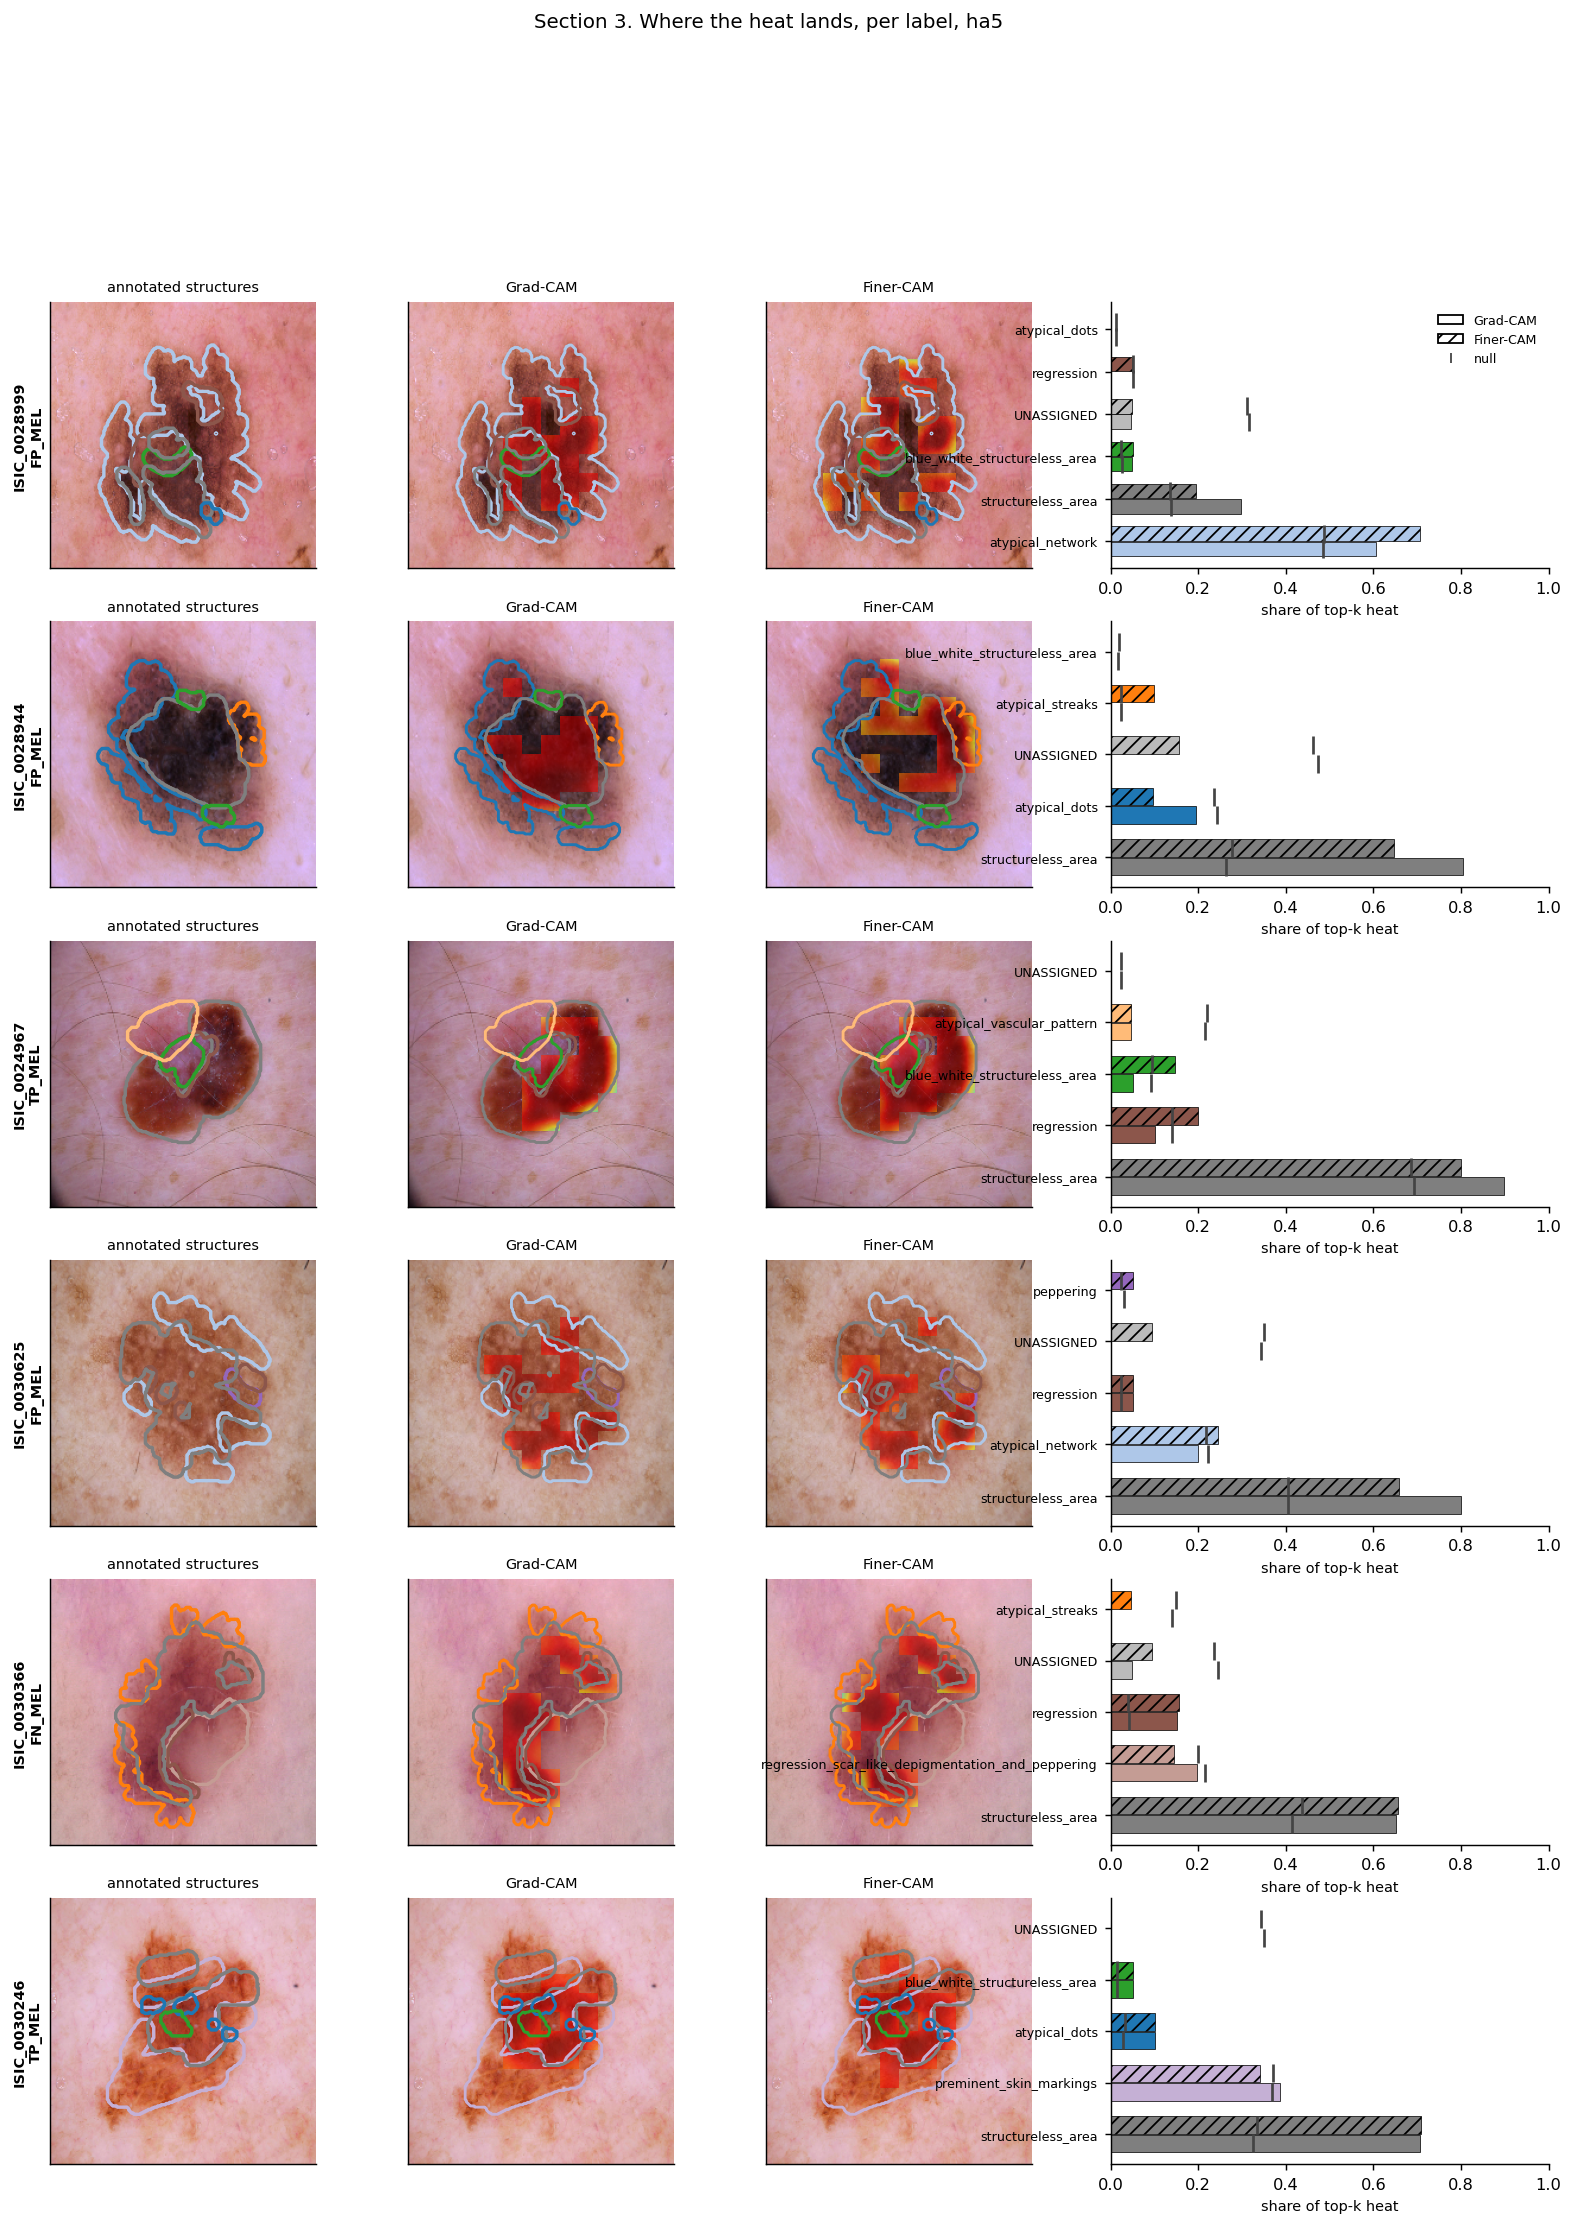

In [11]:
# =============================================================================
# FIGURE. Six cases, most label diversity.
# Bar colour encodes the label. Hatch encodes the CAM. Tick is the null.
# =============================================================================
from matplotlib.patches import Patch

_m_cache = {}                  # masks do not depend on pooling, safe to keep
def label_union_mask(iid, lab):
    key = (iid, lab)
    if key in _m_cache:
        return _m_cache[key]
    acc = None
    for p in qcp[(qcp.Image_ID == iid) & (qcp.label == lab)].mask_path:
        m = np.array(Image.open(p).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    _m_cache[key] = transform_mask(acc, GEOMETRY)[0].astype(float)
    return _m_cache[key]

HATCH = {"Grad-CAM": "", "Finer-CAM": "///"}
LEG = [Patch(facecolor="white", edgecolor="black", hatch=HATCH[c], label=c)
       for c in CAM_TYPES.values()] + \
      [plt.Line2D([], [], marker="|", ls="", color="#444", label="null")]

def case_row(ax, iid, fs=8):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(np.array(Image.open(
        (HAM_ROOT / str(r.image_rel_path)).resolve()).convert("RGB")), GEOMETRY)
    lg = label_grids(iid)
    for a in ax[:3]:
        a.imshow(rgb)
        a.set_xticks([]); a.set_yticks([])
    for lab in lg:
        ax[0].contour(label_union_mask(iid, lab), [0.5],
                      colors=[PAL[lab]], linewidths=1.9)
    ax[0].set_title("annotated structures", fontsize=fs)
    for j, (kind, nm_) in enumerate(CAM_TYPES.items(), start=1):
        cam = load_act(iid, kind)
        if cam is not None:
            c = norm01(cam)
            up = cv2.resize(c, (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_CUBIC)
            s_ = cv2.resize(topk_mask(c, TOP_K).astype(np.float32),
                            (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)
            ax[j].imshow(np.where(s_ > 0.5, up, np.nan), cmap="jet",
                         alpha=0.58, vmin=0, vmax=1)
        for lab in lg:
            ax[j].contour(label_union_mask(iid, lab), [0.5],
                          colors=[PAL[lab]], linewidths=1.6)
        ax[j].set_title(nm_, fontsize=fs)

    sub = S3[S3.image_id == iid]
    piv = (sub.pivot_table(index="label", columns="cam", values="share")
              .reindex(columns=list(CAM_TYPES.values())))
    nul = sub.pivot_table(index="label", columns="cam", values="share_null")
    piv = piv.reindex(sorted(piv.index, key=lambda l: -piv.loc[l].mean()))
    y = np.arange(len(piv))
    for k, cname in enumerate(piv.columns):
        ax[3].barh(y + (k - 0.5) * 0.36, piv[cname], height=0.34,
                   color=[PAL.get(l, "#bbb") for l in piv.index],
                   hatch=HATCH[cname], edgecolor="black", linewidth=0.4)
        ax[3].scatter(nul.loc[piv.index, cname], y + (k - 0.5) * 0.36,
                      marker="|", s=90, color="#444", zorder=5)
    ax[3].set_yticks(y)
    ax[3].set_yticklabels(piv.index, fontsize=fs - 1)
    ax[3].set_xlabel("share of top-k heat", fontsize=fs)
    ax[3].set_xlim(0, 1)

cnt = (S3[S3.label != "UNASSIGNED"].groupby("image_id").label.nunique()
       .sort_values(ascending=False))
SHOW = list(cnt.head(6).index)
fig, axes = plt.subplots(len(SHOW), 4, figsize=(15, 3.1 * len(SHOW)),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
axes = np.atleast_2d(axes)
for i, iid in enumerate(SHOW):
    case_row(axes[i], iid)
    p = pred[pred.image_id == iid].iloc[0]
    axes[i, 0].set_ylabel(f"{iid}\n{p.case_type}", fontsize=8,
                          fontweight="bold")
axes[0, 3].legend(handles=LEG, fontsize=7, frameon=False)
fig.suptitle(f"Section 3. Where the heat lands, per label, {CK}",
             fontsize=11, y=1.00)
fig.savefig(OUT / "s3_case_studies.png")
plt.show()

In [12]:
# =============================================================================
# One page per image, all images with two or more labels.
# =============================================================================
import matplotlib
from PIL import Image as PILImage

PAGES = OUT / "case_pages"
PAGES.mkdir(exist_ok=True)
_bk = matplotlib.get_backend()
matplotlib.use("Agg")

files = []
for iid in sorted(S3.image_id.unique()):
    f, ax = plt.subplots(1, 4, figsize=(15, 3.4),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
    case_row(ax, iid, fs=9)
    ax[3].legend(handles=LEG, fontsize=7, frameon=False)
    p = pred[pred.image_id == iid].iloc[0]
    f.suptitle(f"{iid}   gt {p.gt_label}   pred {p.pred}   {p.case_type}   "
               f"conf {p.confidence:.2f}", fontsize=10, y=1.02)
    fp = PAGES / f"{iid}.png"
    f.savefig(fp, dpi=160, bbox_inches="tight", facecolor="white")
    plt.close(f)
    files.append(fp)

matplotlib.use(_bk)
imgs = [PILImage.open(p).convert("RGB") for p in files]
pdf = OUT / f"case_studies_{POOL_TAG}_{CK}.pdf"
imgs[0].save(pdf, save_all=True, append_images=imgs[1:], resolution=150.0)
print(f"{len(imgs)} pages -> {pdf.relative_to(REPO)}")

33 pages -> results/followup/gap/squash224/case_studies_gap_ha5.pdf


---
## Section 4. Push alignment to failure

**Mauricio's request.** Alpha 5 is not far enough. Find where classification
performance is actually compromised, not just where alignment saturates.
He also asked whether F1 was used. It was not, only AUC. Both are reported
here.

**Two different populations, deliberately.**

| question | evaluated on |
|---|---|
| does classification break | test split, n printed at runtime |
| does the explanation keep improving | the annotated images |
| does the class collapse deepen | test subsample |

**Scoring.** Human feature AUC is reported inside the lesion. The whole grid
version measures lesion localisation, not feature grounding, and is kept only
for comparison. A centre of lesion distance map is the oracle floor.

Failure is the first alpha where test AUC falls more than two standard errors
of the PAIRED difference below the peak.

**Three curves against alpha.**

| curve | measures |
|---|---|
| classification | AUC, F1, balanced accuracy on the test split |
| lesion alignment | CAM agreement with Tschandl lesion masks, what the loss optimised |
| class collapse | correlation between the two class maps |

Failure is defined as the first alpha where test AUC falls more than two
standard errors below its peak.

In [13]:
# =============================================================================
# SECTION 4a. Checkpoints and the test split.
#
# Supports both naming conventions.
#   checkpoint-best-gap-ha0p25.pth                         clean
#   checkpoint-best-foundation_gap_ha0.25_start0_...pth     raw from the sweep
# =============================================================================
import re
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,
                             accuracy_score, recall_score, average_precision_score)

ALPHA_DIR = REPO / "external" / "checkpoints_alpha"
CLEAN_CSV = HAM_ROOT / "mel_nv" / "ham_mel_nv_clean.csv"


def parse_alpha(name):
    if "dal" in name.lower():
        return None
    m = re.search(r"[-_]ha([\d]+(?:[p.]\d+)?)", name)
    return float(m.group(1).replace("p", ".")) if m else None


def parse_pool(name):
    m = re.search(r"[-_](gap|cls)[-_]", name)
    return m.group(1) if m else None


ck_alpha = {}
for d in [CKPT_DIR, ALPHA_DIR]:
    if not d.exists():
        continue
    for f in sorted(d.glob("*.pth")):
        a, p = parse_alpha(f.name), parse_pool(f.name)
        if a is None or p != POOL_TAG:
            continue
        ck_alpha.setdefault(a, f)

A_LIST = sorted(ck_alpha)
print(f"{len(A_LIST)} alpha checkpoints for {POOL_TAG}")
for a in A_LIST:
    print(f"  alpha {a:>6g}   {ck_alpha[a].name}")

if len(A_LIST) < 4:
    print(f"\nFewer than four. Expected the ablation in {ALPHA_DIR}")
    print("The curve will be sparse but the cells still run.")

# ---- test split ------------------------------------------------------------
clean = pd.read_csv(CLEAN_CSV)
clean["image_id"] = clean["image_id"].astype(str).str.strip()

LBL = ("binary_label" if "binary_label" in clean.columns
       else "label_2class" if "label_2class" in clean.columns else None)
if LBL is None:
    raise KeyError(f"no integer label column. found {clean.columns.tolist()}")

test = clean[clean.split == "test"].reset_index(drop=True)
print(f"\ntest split: {len(test)} images")
print(test.dx.value_counts().to_string())
print(f"label column '{LBL}', mapping "
      f"{test.groupby('dx')[LBL].first().to_dict()}")

MEL_LBL = int(test[test.dx == "mel"][LBL].iloc[0])
assert MEL_LBL == MEL_IDX, f"label mismatch, mel is {MEL_LBL} not {MEL_IDX}"

# ---- preload once, reused across every checkpoint --------------------------
print("\npreloading test images")
X_test, Y_test, ID_test = [], [], []
for _, r in test.iterrows():
    p = (HAM_ROOT / str(r.image_rel_path)).resolve()
    if not p.exists():
        continue
    X_test.append(PREPROCESS(Image.open(p).convert("RGB")))
    Y_test.append(int(r[LBL]))
    ID_test.append(r.image_id)

X_test = torch.stack(X_test)
Y_test = np.array(Y_test)
print(f"loaded {len(X_test)}  MEL {int((Y_test == MEL_IDX).sum())}  "
      f"NV {int((Y_test == NV_IDX).sum())}")

# subsample for the gradient based metrics
rng = np.random.default_rng(0)
SUB_N = min(60, len(ID_test))
SUB = rng.choice(len(ID_test), SUB_N, replace=False)
print(f"CAM metrics on a {SUB_N} image subsample")

10 alpha checkpoints for gap
  alpha      0   checkpoint-best-gap-ha0.pth
  alpha    0.1   checkpoint-best-gap-ha0p1.pth
  alpha   0.25   checkpoint-best-gap-ha0p25.pth
  alpha    0.5   checkpoint-best-gap-ha0p5.pth
  alpha      1   checkpoint-best-gap-ha1.pth
  alpha      3   checkpoint-best-gap-ha3.pth
  alpha      5   checkpoint-best-gap-ha5.pth
  alpha      7   checkpoint-best-gap-ha7.pth
  alpha     11   checkpoint-best-gap-ha11.pth
  alpha     17   checkpoint-best-gap-ha17.pth

test split: 1021 images
dx
nv     951
mel     70
label column 'binary_label', mapping {'mel': 0, 'nv': 1}

preloading test images
loaded 1021  MEL 70  NV 951
CAM metrics on a 60 image subsample


In [14]:
# =============================================================================
# SECTION 4b. Classification on the test split. No gradients, batched.
#
# TWO FAILURE CRITERIA. Consecutive checkpoints are highly correlated, so the
# paired test detects drops far smaller than anything that matters. Report
#   detectable  paired drop exceeding two SE of the difference
#   meaningful  absolute drop exceeding two single model SE at the peak
# AP is the primary metric. At 7 percent prevalence AUC is dominated by the
# majority class and understates the cost to melanoma ranking.
# =============================================================================
def load_alpha_model(path, train_mode=False):
    obj = torch.load(path, map_location="cpu", weights_only=False)
    raw, _ = extract_checkpoint_state_dict(obj)
    got = infer_checkpoint_pooling(obj, raw)
    if got is not None and got != POOLING:
        raise RuntimeError(f"{path.name}: pooling {got}, expected {POOLING}")
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    st = remap_norm_keys_for_pooling(st, m)
    miss, unexp = m.load_state_dict(st, strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    if bad:
        return None, bad
    m.to(DEVICE).eval()
    if train_mode:
        for q in m.parameters():
            q.requires_grad_(True)
    return m, None

def free(m):
    del m
    if DEVICE == "mps":
        torch.mps.empty_cache()

N_BOOT = 1000
BOOT_IDX = np.array([np.random.default_rng(s).choice(len(Y_test), len(Y_test),
                                                     replace=True)
                     for s in range(N_BOOT)])
OK_BOOT = [i for i in BOOT_IDX
           if len(np.unique((Y_test[i] == MEL_IDX).astype(int))) > 1]

y_mel = (Y_test == MEL_IDX).astype(int)

def boot_vec(p, fn):
    """Bootstrap vector on the shared resample indices."""
    return np.array([fn(y_mel[i], p[i]) for i in OK_BOOT])

rows, BOOT = [], {}
for a in A_LIST:
    m, bad = load_alpha_model(ck_alpha[a])
    if m is None:
        print(f"  alpha {a:g}: SKIP, critical keys {bad}")
        continue
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_test), 32):
            out = m(X_test[i:i + 32].to(DEVICE))
            lg = out["logits"] if isinstance(out, dict) else (
                out[0] if isinstance(out, (tuple, list)) else out)
            probs.append(torch.softmax(lg, 1).cpu().numpy())
    probs = np.vstack(probs)
    yhat = probs.argmax(1)
    p_mel = probs[:, MEL_IDX]
    BOOT[a] = {"auc": boot_vec(p_mel, roc_auc_score),
               "ap": boot_vec(p_mel, average_precision_score)}
    rows.append({
        "alpha": a, "n": len(Y_test),
        "auc": roc_auc_score(y_mel, p_mel),
        "auc_se": float(BOOT[a]["auc"].std()),
        "ap_mel": average_precision_score(y_mel, p_mel),
        "ap_se": float(BOOT[a]["ap"].std()),
        "f1_macro": f1_score(Y_test, yhat, average="macro"),
        "f1_mel": f1_score(Y_test, yhat, pos_label=MEL_IDX),
        "bacc": balanced_accuracy_score(Y_test, yhat),
        "acc": accuracy_score(Y_test, yhat),
        "recall_mel": recall_score(Y_test, yhat, pos_label=MEL_IDX),
        "recall_nv": recall_score(Y_test, yhat, pos_label=NV_IDX),
    })
    free(m)
    print(f"  alpha {a:>6g}   AUC {rows[-1]['auc']:.4f}   "
          f"AP {rows[-1]['ap_mel']:.4f}   bacc {rows[-1]['bacc']:.4f}")

CLS = pd.DataFrame(rows).sort_values("alpha").reset_index(drop=True)

# paired differences against the AP peak
a_pk = CLS.loc[CLS.ap_mel.idxmax(), "alpha"]
for met in ["auc", "ap"]:
    col = "auc" if met == "auc" else "ap_mel"
    top = CLS.loc[CLS.alpha == a_pk, col].iloc[0]
    CLS[f"d_{met}"] = top - CLS[col]
    CLS[f"d_{met}_se"] = CLS.alpha.map(
        lambda a: float((BOOT[a_pk][met] - BOOT[a][met]).std())
        if a != a_pk else 0.0)
    CLS[f"z_{met}"] = CLS[f"d_{met}"] / CLS[f"d_{met}_se"].replace(0, np.nan)
    CLS[f"rel_{met}"] = CLS[f"d_{met}"] / top

CLS.to_csv(OUT / "s4_classification.csv", index=False)

pk = CLS.loc[CLS.alpha == a_pk].iloc[0]
MARGIN_AUC = 2 * pk.auc_se
MARGIN_AP = 2 * pk.ap_se

print("\n" + "=" * 104)
print(f"SECTION 4b  test split, n={len(Y_test)}, MEL {int(y_mel.sum())}, "
      f"prevalence {y_mel.mean():.3f}, {POOL_TAG.upper()}")
print("=" * 104)
print(CLS[["alpha", "auc", "auc_se", "d_auc", "z_auc",
           "ap_mel", "ap_se", "d_ap", "z_ap", "rel_ap",
           "bacc", "recall_mel"]].round(4).to_string(index=False))

print(f"\npeak at alpha {a_pk:g}. AUC {pk.auc:.4f} SE {pk.auc_se:.4f}, "
      f"AP {pk.ap_mel:.4f} SE {pk.ap_se:.4f}")
print(f"meaningful margin, two single model SE: AUC {MARGIN_AUC:.4f}, "
      f"AP {MARGIN_AP:.4f}")

for met, marg, lab in [("auc", MARGIN_AUC, "AUC"), ("ap", MARGIN_AP, "AP")]:
    det = CLS[(CLS.alpha > a_pk) & (CLS[f"z_{met}"] > 2)]
    mea = CLS[(CLS.alpha > a_pk) & (CLS[f"d_{met}"] > marg)]
    a_det = det.alpha.iloc[0] if len(det) else None
    a_mea = mea.alpha.iloc[0] if len(mea) else None
    print(f"\n  {lab}  detectable from alpha {a_det}, "
          f"meaningful from alpha {a_mea}")
    if a_mea is not None:
        r = mea.iloc[0]
        print(f"        at alpha {r.alpha:g}: drop {r[f'd_{met}']:.4f} "
              f"({r[f'rel_{met}']:.1%} relative), z {r[f'z_{met}']:.1f}")

worst = CLS.iloc[-1]
print(f"\n  across the full range AUC falls {CLS.rel_auc.max():.1%} relative, "
      f"AP falls {CLS.rel_ap.max():.1%}")
print(f"  AP degrades {CLS.rel_ap.max() / max(CLS.rel_auc.max(), 1e-9):.0f}x "
      f"faster in relative terms. AUC understates the cost at this prevalence.")

  alpha      0   AUC 0.9749   AP 0.7929   bacc 0.9111
  alpha    0.1   AUC 0.9742   AP 0.7887   bacc 0.9111
  alpha   0.25   AUC 0.9733   AP 0.7834   bacc 0.9100
  alpha    0.5   AUC 0.9721   AP 0.7807   bacc 0.9111
  alpha      1   AUC 0.9701   AP 0.7659   bacc 0.9095
  alpha      3   AUC 0.9621   AP 0.6907   bacc 0.8926
  alpha      5   AUC 0.9623   AP 0.6965   bacc 0.8947
  alpha      7   AUC 0.9536   AP 0.5840   bacc 0.9008
  alpha     11   AUC 0.9475   AP 0.5145   bacc 0.8971
  alpha     17   AUC 0.9382   AP 0.4486   bacc 0.8828

SECTION 4b  test split, n=1021, MEL 70, prevalence 0.069, GAP
 alpha    auc  auc_se  d_auc  z_auc  ap_mel  ap_se   d_ap   z_ap  rel_ap   bacc  recall_mel
  0.00 0.9749  0.0056 0.0000    NaN  0.7929 0.0416 0.0000    NaN  0.0000 0.9111      0.9714
  0.10 0.9742  0.0057 0.0007 2.3971  0.7887 0.0419 0.0042 1.3915  0.0052 0.9111      0.9714
  0.25 0.9733  0.0059 0.0016 2.7539  0.7834 0.0431 0.0095 1.8780  0.0120 0.9100      0.9714
  0.50 0.9721  0.0062 0.0028 

In [15]:
# =============================================================================
# SECTION 4c. Explanation quality and class collapse, one pass per checkpoint.
#
# Per image outputs are retained so the paired tests later need no rerun.
#   lesion_auc   CAM against the lesion mask, test subsample
#   human_whole  CAM against the clinician MEL union, whole grid
#   human_in     same union, scored INSIDE the lesion only
#   centre       distance to lesion centroid, oracle floor
# =============================================================================
from scipy.ndimage import center_of_mass

LES_TEST = {}
for i in SUB:
    r = test[test.image_id == ID_test[i]].iloc[0]
    p = (HAM_ROOT / str(r.mask_rel_path)).resolve()
    if p.exists():
        LES_TEST[ID_test[i]] = mask_to_cam_grid_geom(
            np.array(Image.open(p).convert("L")) > 127, GEOMETRY) >= 0.5
print(f"lesion masks for {len(LES_TEST)} of {len(SUB)} subsample images")

HUM = {i: mel_union_grid(i) for i in eval_df.image_id}   # from Section 2
HUM = {k: v for k, v in HUM.items()
       if v is not None and k in LESION and LESION[k].sum() >= 8
       and 0 < v[LESION[k]].sum() < LESION[k].sum()}
print(f"clinician MEL unions usable inside the lesion for {len(HUM)} images")

def centre_map(les):
    cy, cx = center_of_mass(les.astype(float))
    yy, xx = np.mgrid[0:CAM_GRID, 0:CAM_GRID]
    return norm01(-np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2))

B = pd.DataFrame([{
    "image_id": iid,
    "centre": float(roc_auc_score(HUM[iid][LESION[iid]].astype(int),
                                  centre_map(LESION[iid])[LESION[iid]])),
    "union_frac_of_lesion": float(HUM[iid][LESION[iid]].mean()),
    "lesion_patches": int(LESION[iid].sum()),
} for iid in HUM])
B.to_csv(OUT / "s4c_centre_baseline.csv", index=False)
print(f"centre oracle {B.centre.median():.3f}, union covers "
      f"{B.union_frac_of_lesion.median():.3f} of a "
      f"{B.lesion_patches.median():.0f} patch lesion")

gt = eval_df.set_index("image_id").gt_label.to_dict()
per_img, rows = [], []
for a in A_LIST:
    m, bad = load_alpha_model(ck_alpha[a], train_mode=True)
    if m is None:
        continue
    les_auc, ptg, corr = [], [], []
    for i in SUB:
        iid = ID_test[i]
        if iid not in LES_TEST:
            continue
        cm, cn = class_cams(m, X_test[i:i + 1].to(DEVICE))
        tgt = cm if Y_test[i] == MEL_IDX else cn
        L = LES_TEST[iid]
        if 0 < L.sum() < L.size:
            les_auc.append(roc_auc_score(L.ravel(), norm01(tgt).ravel()))
            ptg.append(float(L[np.unravel_index(np.argmax(tgt), tgt.shape)]))
        corr.append(float(np.corrcoef(norm01(cm).ravel(),
                                      norm01(cn).ravel())[0, 1]))
    for iid, u in HUM.items():
        L = LESION[iid]
        cm, cn = class_cams(m, load_tensor(
            eval_df.set_index("image_id").loc[iid].image_rel_path))
        tgt = norm01(cm if gt[iid] == "MEL" else cn)
        if tgt[L].std() < 1e-8:
            continue
        per_img.append({"alpha": a, "image_id": iid, "pooling": POOL_TAG,
                        "gt_label": gt[iid],
                        "human_whole": float(roc_auc_score(u.ravel().astype(int),
                                                           tgt.ravel())),
                        "human_in": float(roc_auc_score(u[L].astype(int), tgt[L]))})
    h = pd.DataFrame([p for p in per_img if p["alpha"] == a])
    rows.append({
        "alpha": a,
        "lesion_auc": float(np.median(les_auc)) if les_auc else np.nan,
        "lesion_pointing": float(np.mean(ptg)) if ptg else np.nan,
        "human_whole": float(h.human_whole.median()) if len(h) else np.nan,
        "human_in": float(h.human_in.median()) if len(h) else np.nan,
        "class_corr": float(np.median(corr)),
        "n_test": len(les_auc), "n_human": len(h),
    })
    free(m)
    print(f"  alpha {a:>6g}   lesion {rows[-1]['lesion_auc']:.3f}   "
          f"human whole {rows[-1]['human_whole']:.3f}   "
          f"in lesion {rows[-1]['human_in']:.3f}   "
          f"collapse {rows[-1]['class_corr']:+.3f}")

P = pd.DataFrame(per_img)
P.to_csv(OUT / "s4b_human_auc_per_image.csv", index=False)
S4 = CLS.merge(pd.DataFrame(rows), on="alpha", how="outer").sort_values("alpha")
S4["pooling"] = POOL_TAG
S4["centre"] = B.centre.median()
S4.to_csv(OUT / "s4_alpha_failure.csv", index=False)

print("\n" + "=" * 100)
print(f"SECTION 4  full ablation, {POOL_TAG.upper()}")
print("=" * 100)
print(S4[["alpha", "auc", "ap_mel", "bacc", "lesion_auc", "lesion_pointing",
          "human_whole", "human_in", "class_corr"]]
      .round(4).to_string(index=False))

print("\nmodel versus the centre oracle, inside the lesion")
n_tests = len(P.alpha.unique())
for a in sorted(P.alpha.unique()):
    M = P[P.alpha == a].merge(B, on="image_id")
    d = M.human_in - M.centre
    _, pv = wilcoxon(M.human_in, M.centre)
    pb = min(pv * n_tests, 1.0)
    print(f"  alpha {a:>6g}   model {M.human_in.median():.3f}   "
          f"centre {M.centre.median():.3f}   delta {d.median():+.3f}   "
          f"p {pv:.2e}   p_bonf {pb:.2e}   wins {(d > 0).sum()}/{len(M)}   "
          f"{'loses' if pb < 0.05 else 'indistinguishable'}")

A_PICK = max([a for a in P.alpha.unique() if a <= 3], default=P.alpha.max())
M = P[P.alpha == A_PICK].merge(B, on="image_id")
print(f"\nsubset split at alpha {A_PICK:g}")
for tag, sub in [("union < 0.5 of lesion", M[M.union_frac_of_lesion < 0.5]),
                 ("union >= 0.5", M[M.union_frac_of_lesion >= 0.5])]:
    if len(sub) < 3:
        print(f"  {tag:24} n {len(sub)}  too few")
        continue
    dd = sub.human_in - sub.centre
    print(f"  {tag:24} n {len(sub):3d}   model {sub.human_in.median():.3f}   "
          f"centre {sub.centre.median():.3f}   delta {dd.median():+.3f}   "
          f"wins {(dd > 0).sum()}/{len(sub)}")

lesion masks for 60 of 60 subsample images
clinician MEL unions usable inside the lesion for 31 images
centre oracle 0.828, union covers 0.680 of a 50 patch lesion
  alpha      0   lesion 0.417   human whole 0.576   in lesion 0.543   collapse -0.243
  alpha    0.1   lesion 0.980   human whole 0.948   in lesion 0.696   collapse +0.854
  alpha   0.25   lesion 0.984   human whole 0.947   in lesion 0.707   collapse +0.926
  alpha    0.5   lesion 0.986   human whole 0.961   in lesion 0.716   collapse +0.947
  alpha      1   lesion 0.988   human whole 0.963   in lesion 0.723   collapse +0.963
  alpha      3   lesion 0.988   human whole 0.964   in lesion 0.750   collapse +0.967
  alpha      5   lesion 0.983   human whole 0.965   in lesion 0.743   collapse +0.970
  alpha      7   lesion 0.988   human whole 0.962   in lesion 0.749   collapse +0.980
  alpha     11   lesion 0.988   human whole 0.963   in lesion 0.751   collapse +0.987
  alpha     17   lesion 0.989   human whole 0.964   in lesion 

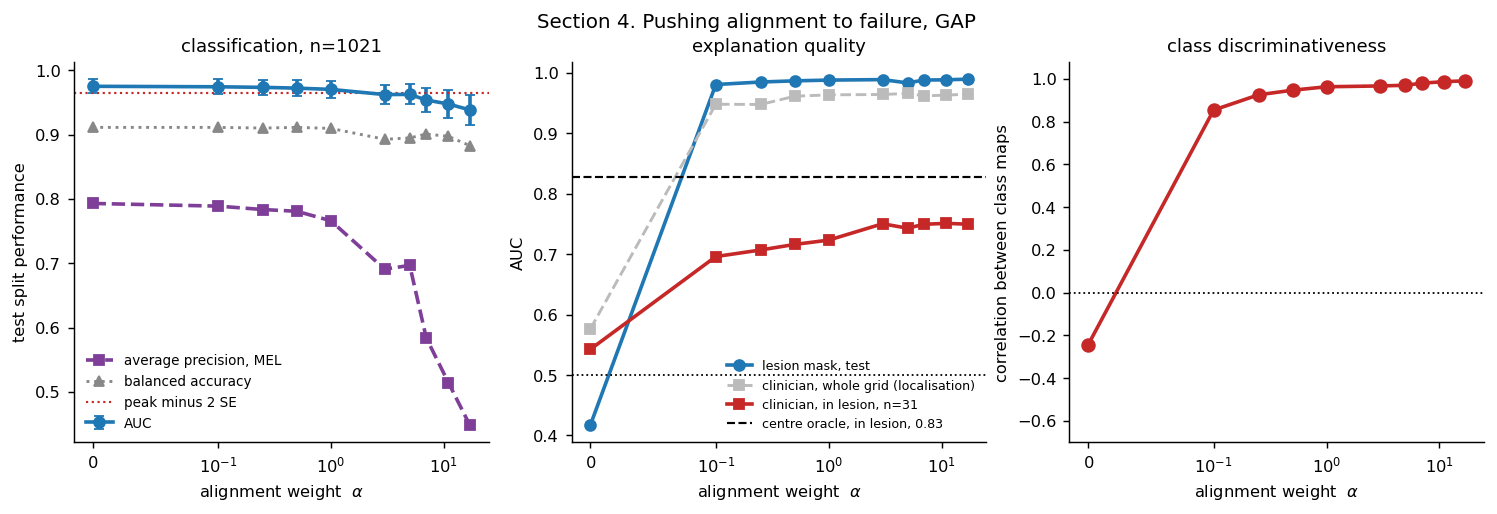

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
if S4.alpha.max() / max(S4[S4.alpha > 0].alpha.min(), 0.01) > 20:
    for a_ in ax:
        a_.set_xscale("symlog", linthresh=S4[S4.alpha > 0].alpha.min())
for a_ in ax:
    a_.set_xlabel(r"alignment weight  $\alpha$")
    a_.set_xscale("symlog", linthresh=0.1)

pk = S4.loc[S4.auc.idxmax()]
ax[0].errorbar(S4.alpha, S4.auc, yerr=2 * S4.auc_se, fmt="o-", color=C_ATTN,
               lw=2, ms=6, capsize=3, label="AUC")
ax[0].plot(S4.alpha, S4.ap_mel, "s--", color=C_ACT, lw=2, ms=6,
           label="average precision, MEL")
ax[0].plot(S4.alpha, S4.bacc, "^:", color="#888", lw=1.6, ms=6,
           label="balanced accuracy")
ax[0].axhline(pk.auc - 2 * pk.auc_se, color=C_MEL, ls=":", lw=1.2,
              label="peak minus 2 SE")
ax[0].set_ylabel("test split performance")
ax[0].set_title(f"classification, n={int(S4.n.dropna().iloc[0])}", fontsize=10)
ax[0].legend(frameon=False, fontsize=7.5)

n_h = int(S4.n_human.dropna().max())
ax[1].plot(S4.alpha, S4.lesion_auc, "o-", color=C_ATTN, lw=2, ms=6,
           label="lesion mask, test")
ax[1].plot(S4.alpha, S4.human_whole, "s--", color="#bbb", lw=1.6, ms=6,
           label=f"clinician, whole grid (localisation)")
ax[1].plot(S4.alpha, S4.human_in, "s-", color=C_MEL, lw=2, ms=6,
           label=f"clinician, in lesion, n={n_h}")
ax[1].axhline(S4.centre.iloc[0], color="k", ls="--", lw=1.2,
              label=f"centre oracle, in lesion, {S4.centre.iloc[0]:.2f}")
ax[1].axhline(0.5, color="k", ls=":", lw=1)
ax[1].set_ylabel("AUC")
ax[1].set_title("explanation quality", fontsize=10)
ax[1].legend(frameon=False, fontsize=7, loc="lower right")

ax[2].plot(S4.alpha, S4.class_corr, "o-", color=C_MEL, lw=2, ms=7)
ax[2].axhline(0, color="k", ls=":", lw=1)
ax[2].set_ylim(min(-0.7, S4.class_corr.min() - 0.05), 1.08)
ax[2].set_ylabel("correlation between class maps")
ax[2].set_title("class discriminativeness", fontsize=10)

fig.suptitle(f"Section 4. Pushing alignment to failure, {POOL_TAG.upper()}",
             fontsize=11)
fig.savefig(OUT / "s4_failure_curve.png")
plt.show()

In [17]:
# =============================================================================
# Where each thing breaks. All statements derived.
# =============================================================================
a_pk = CLS.loc[CLS.ap_mel.idxmax(), "alpha"]
pk = S4.loc[S4.alpha == a_pk].iloc[0]
MARGIN_AUC, MARGIN_AP = 2 * pk.auc_se, 2 * pk.ap_se
a_min = S4[S4.alpha > 0].alpha.min()

def first(mask):
    s = S4[(S4.alpha > a_pk) & mask]
    return float(s.alpha.iloc[0]) if len(s) else None

def saturation(col, frac=0.95):
    s = S4.dropna(subset=[col]).sort_values("alpha")
    if len(s) < 3:
        return None, None
    lo, hi = s[col].iloc[0], s[col].max()
    if hi - lo < 1e-6:
        return None, None
    ok = s[s[col] >= lo + frac * (hi - lo)]
    a = float(ok.alpha.iloc[0]) if len(ok) else None
    return a, (a == a_min)

sat_les, les_edge = saturation("lesion_auc")
sat_hum, hum_edge = saturation("human_in")
col_a = S4[S4.class_corr > 0.9].alpha.min() if (S4.class_corr > 0.9).any() else None
a_det_auc = first(S4.z_auc > 2)
a_mea_auc = first(S4.d_auc > MARGIN_AUC)
a_mea_ap = first(S4.d_ap > MARGIN_AP)
cen = S4.centre.iloc[0]

print("=" * 88)
print(f"WHERE EACH THING BREAKS, {POOL_TAG.upper()}")
print("=" * 88)
print(f"  peak performance               alpha {a_pk:g}   AUC {pk.auc:.4f}   "
      f"AP {pk.ap_mel:.4f}")
print(f"  lesion localisation saturates  alpha {sat_les}"
      f"{'  UNRESOLVED, smallest alpha tested' if les_edge else ''}")
print(f"  in lesion grounding saturates  alpha {sat_hum}"
      f"{'  UNRESOLVED, smallest alpha tested' if hum_edge else ''}")
print(f"  class collapse complete        alpha {col_a}")
print(f"  AUC drop detectable            alpha {a_det_auc}")
print(f"  AUC drop meaningful            alpha {a_mea_auc}")
print(f"  AP  drop meaningful            alpha {a_mea_ap}")
print(f"  centre oracle, in lesion       {cen:.3f}   "
      f"best model {S4.human_in.max():.3f}   model never wins")

print("\n" + "-" * 88)
print("DRAFT TEXT\n")
n_test, n_hum = int(S4.n.dropna().iloc[0]), int(S4.n_human.dropna().max())
print(f"""Alignment weight was swept across {len(S4)} values from {S4.alpha.min():g} to
{S4.alpha.max():g}. Classification was evaluated on the held out test split of {n_test}
images, {int((Y_test == MEL_IDX).sum())} of them melanoma. Explanation quality was evaluated
against lesion masks on a test subsample and against clinician features on
{n_hum} annotated images.""")

print(f"""
Because consecutive checkpoints are highly correlated, the paired test detects
AUC drops from alpha {a_det_auc} that are far below any meaningful scale. Using a margin of
two single model standard errors, AUC degrades from alpha {a_mea_auc} and average
precision from alpha {a_mea_ap}. Across the full range AUC falls {S4.rel_auc.max():.1%} relative
while average precision falls {S4.rel_ap.max():.1%}. At a melanoma prevalence of
{(Y_test == MEL_IDX).mean():.3f} the area under the ROC curve substantially understates the cost.""")

order = sorted([("lesion localisation", sat_les),
                ("class collapse", col_a),
                ("AP degradation", a_mea_ap)],
               key=lambda t: (t[1] is None, t[1]))
print(f"""
The curves do not decouple cleanly. In order of alpha: """
      + ", ".join(f"{k} at {v:g}" for k, v in order if v is not None) + ".")
if col_a is not None and a_mea_ap is not None:
    rel = ("before" if col_a < a_mea_ap else
           "after" if col_a > a_mea_ap else "at the same alpha as")
    print(f"""Class discriminativeness collapses {rel} average precision
degrades, so there is no alpha window that buys grounding without cost.""")

print(f"""
Feature level grounding never succeeds. Scored inside the lesion the clinician
feature AUC peaks at {S4.human_in.max():.3f}, below the {cen:.3f} reached by a distance transform
of the lesion mask that uses no model output. The model does not beat this
baseline at any alpha tested. Alignment to lesion masks produces localisation,
not feature grounding.""")

WHERE EACH THING BREAKS, GAP
  peak performance               alpha 0   AUC 0.9749   AP 0.7929
  lesion localisation saturates  alpha 0.1  UNRESOLVED, smallest alpha tested
  in lesion grounding saturates  alpha 3.0
  class collapse complete        alpha 0.25
  AUC drop detectable            alpha 0.1
  AUC drop meaningful            alpha 3.0
  AP  drop meaningful            alpha 3.0
  centre oracle, in lesion       0.828   best model 0.751   model never wins

----------------------------------------------------------------------------------------
DRAFT TEXT

Alignment weight was swept across 10 values from 0 to
17. Classification was evaluated on the held out test split of 1021
images, 70 of them melanoma. Explanation quality was evaluated
against lesion masks on a test subsample and against clinician features on
31 annotated images.

Because consecutive checkpoints are highly correlated, the paired test detects
AUC drops from alpha 0.1 that are far below any meaningful scale. Using

In [18]:
print("head weight correlation, w_mel against w_nv")
for a in A_LIST:
    m, _ = load_alpha_model(ck_alpha[a])
    if m is None:
        continue
    W = _unwrap_model(m).head.weight.detach().cpu().numpy()
    print(f"  alpha {a:>6g}   {float(np.corrcoef(W[0], W[1])[0, 1]):+.4f}")
    free(m)

head weight correlation, w_mel against w_nv
  alpha      0   -0.1029
  alpha    0.1   -0.0963
  alpha   0.25   -0.0903
  alpha    0.5   -0.0838
  alpha      1   -0.0769
  alpha      3   -0.0676
  alpha      5   -0.0634
  alpha      7   -0.0614
  alpha     11   -0.0585
  alpha     17   -0.0567


In [20]:
qc = pd.read_csv(QC_CSV)
print(f"rows {len(qc)}  qc_pass {qc.qc_pass.sum()}  images {qc.Image_ID.nunique()}")
q = qc.query("qc_pass")
print(f"\npass: {q.Image_ID.nunique()} images, {len(q)} annotations")

clean = pd.read_csv(CLEAN_CSV)
clean["image_id"] = clean.image_id.astype(str).str.strip()
m = clean[clean.image_id.isin(q.Image_ID)]
print("\nsplit x class for annotated images")
print(pd.crosstab(m.split, m.dx).to_string())

print("\nlabel x label_group")
print(pd.crosstab(q.label, q.label_group).to_string())

print("\nannotations per image")
print(q.groupby("Image_ID").size().describe().round(2).to_string())

print("\nlabel_group coverage per image")
g = q.groupby("Image_ID").label_group.agg(lambda s: tuple(sorted(set(s))))
print(g.value_counts().to_string())

rows 105  qc_pass 100  images 34

pass: 34 images, 100 annotations

split x class for annotated images
dx     mel  nv
split         
test    16  18

label x label_group
label_group                                        COARSE  MEL  NV  OTHER
label                                                                    
atypical_dots                                           0    8   0      0
atypical_network                                        0   15   0      0
atypical_streaks                                        0    4   0      0
atypical_vascular_pattern                               0    3   0      0
blue_white_structureless_area                           0    9   0      0
diagnostic_region                                       3    0   0      0
homogeneous                                             0    0   3      0
negative_network                                        0    1   0      0
peppering                                               0    2   0      0
preminent_skin_ma

In [21]:
q2 = q.merge(clean[["image_id", "dx"]], left_on="Image_ID",
             right_on="image_id", how="left")
print("label x dx")
print(pd.crosstab(q2.label, q2.dx).to_string())

print("\nper image group presence")
gp = q.groupby("Image_ID").label_group.agg(lambda s: set(s))
info = pd.DataFrame({
    "has_mel": gp.apply(lambda s: "MEL" in s),
    "has_nv": gp.apply(lambda s: "NV" in s),
}).join(clean.set_index("image_id").dx)
print(pd.crosstab([info.has_mel, info.has_nv], info.dx).to_string())

print("\nMEL union fraction of lesion, with and without structureless_area")
rows = []
for iid in q.Image_ID.unique():
    L = LESION.get(iid)
    if L is None or L.sum() < 8:
        continue
    sub = q[q.Image_ID == iid]
    def union(df):
        acc = np.zeros((CAM_GRID, CAM_GRID), bool)
        for _, r in df.iterrows():
            m = np.array(Image.open(r.mask_path).convert("L")) > 127
            acc |= mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5
        return acc
    mel_all = union(sub[sub.label_group == "MEL"])
    mel_nosa = union(sub[(sub.label_group == "MEL")
                         & (sub.label != "structureless_area")])
    rows.append({
        "image_id": iid, "lesion": int(L.sum()),
        "with_sa": float((mel_all & L).sum() / L.sum()),
        "without_sa": float((mel_nosa & L).sum() / L.sum()),
        "compl_with_sa": int((L & ~mel_all).sum()),
        "compl_without_sa": int((L & ~mel_nosa).sum()),
    })
U = pd.DataFrame(rows)
print(U[["with_sa", "without_sa", "compl_with_sa",
         "compl_without_sa"]].describe().round(3).to_string())
print(f"\nimages with complement under 5 patches: "
      f"with SA {int((U.compl_with_sa < 5).sum())}, "
      f"without SA {int((U.compl_without_sa < 5).sum())} of {len(U)}")

label x dx
dx                                                 mel  nv
label                                                     
atypical_dots                                        5   3
atypical_network                                     6   9
atypical_streaks                                     3   1
atypical_vascular_pattern                            3   0
blue_white_structureless_area                        6   3
diagnostic_region                                    1   2
homogeneous                                          0   3
negative_network                                     0   1
peppering                                            1   1
preminent_skin_markings                              3   0
regression                                           6   3
regression_scar_like_depigmentation_and_peppering    3   1
regular_network                                      1   4
small_hyperpigmented_area                            1   1
structureless_area                           

In [41]:
# =============================================================================
# ALIGNMENT TWO. Feature mask builder.
#
# Two channels per image at NATIVE resolution so the paired transform can
# rotate and flip them in lockstep with the image. Downsampling to the CAM
# grid happens inside the training loop.
#
# POSITIVE EVIDENCE ONLY. No inverted targets. The absence of melanoma
# features is not evidence of nevus, so the opposite channel is suppressed
# to zero rather than filled with the complement.
#
#   rule        channel 0 MEL          channel 1 NV
#   mel_only    feature union          zero
#   nv_only     zero                   feature union
#   both        MEL union              NV union minus MEL
#
# Clean nevus anchors are added in the next cell, whole lesion as NV
# evidence, MEL zero. Benign diagnosis is a global gestalt judgement,
# melanoma diagnosis is focal and feature based. The asymmetry in the
# targets mirrors a real asymmetry in the clinical reasoning.
# =============================================================================
from PIL import Image
import numpy as np, pandas as pd
from pathlib import Path

SA          = "structureless_area"     # 13 mel / 16 nv, no class information
EXCLUDE_MEL = {SA}
MIN_PATCHES = 3
N_FOLDS     = 5
SEED        = 0

FEAT_DIR = HAM_ROOT / "mel_nv" / "feature_masks"
FEAT_DIR.mkdir(parents=True, exist_ok=True)
A2_DIR   = HAM_ROOT / "mel_nv"
MANIFEST = REPO / "results" / "alignment2" / "feature_masks_manifest.csv"
MANIFEST.parent.mkdir(parents=True, exist_ok=True)

qcp   = pd.read_csv(QC_CSV).query("qc_pass")
clean = pd.read_csv(CLEAN_CSV)
clean["image_id"] = clean.image_id.astype(str).str.strip()
meta = clean.set_index("image_id")

def to_grid(m):
    return mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5

def native_union(sub, shape):
    """Union of annotation masks at native resolution."""
    acc = np.zeros(shape, bool)
    for p in sub.mask_path:
        acc |= np.array(Image.open(p).convert("L")) > 127
    return acc

rows = []
for iid in sorted(qcp.Image_ID.unique()):
    if iid not in meta.index:
        rows.append({"image_id": iid, "usable": False, "why": "not in clean csv"})
        continue
    r  = meta.loc[iid]
    lp = (HAM_ROOT / str(r.mask_rel_path)).resolve()
    if not lp.exists():
        rows.append({"image_id": iid, "usable": False, "why": "no lesion mask"})
        continue
    L = np.array(Image.open(lp).convert("L")) > 127

    sub   = qcp[qcp.Image_ID == iid]
    mel_u = native_union(sub[(sub.label_group == "MEL")
                             & (~sub.label.isin(EXCLUDE_MEL))], L.shape) & L
    nv_u  = native_union(sub[sub.label_group == "NV"], L.shape) & L
    has_mel, has_nv = mel_u.any(), nv_u.any()
    is_nv = (r.dx == "nv")

    # The complement is only usable when it is a region, not a rim. A large
    # MEL union leaves a thin boundary ring, which would train the NV channel
    # as a rim detector. Fall back to suppression in that case.
    MAX_MEL_FRAC, MIN_COMPL = 0.6, 5

    if has_mel and has_nv:
        rule, mt, nt = "both_annotated", mel_u, nv_u & ~mel_u
    elif has_mel and is_nv:
        mgt, Lgt = to_grid(mel_u), to_grid(L)
        compl_g = Lgt & ~mgt
        frac = mgt.sum() / max(Lgt.sum(), 1)
        if compl_g.sum() >= MIN_COMPL and frac <= MAX_MEL_FRAC:
            rule, mt, nt = "mel_on_nevus", mel_u, L & ~mel_u
        else:
            rule, mt, nt = "mel_only", mel_u, np.zeros_like(L)
    elif has_mel:
        rule, mt, nt = "mel_only", mel_u, np.zeros_like(L)
    elif has_nv:
        rule, mt, nt = "nv_only", np.zeros_like(L), nv_u
    else:
        rows.append({"image_id": iid, "usable": False,
                     "why": "no MEL or NV target after exclusions"})
        continue

    mg, ng, Lg = to_grid(mt), to_grid(nt), to_grid(L)
    contested  = int((mg & ng).sum())
    ng = ng & ~mg                      # MEL priority, same rule in the loop

    if max(mg.sum(), ng.sum()) < MIN_PATCHES:
        rows.append({"image_id": iid, "usable": False,
                     "why": f"target too small, mel {mg.sum()} nv {ng.sum()}"})
        continue

    mp, npp = FEAT_DIR / f"{iid}_mel.png", FEAT_DIR / f"{iid}_nv.png"
    Image.fromarray((mt * 255).astype(np.uint8)).save(mp)
    Image.fromarray((nt * 255).astype(np.uint8)).save(npp)

    rows.append({
        "image_id": iid, "usable": True, "rule": rule, "dx": r.dx,
        "binary_label": int(r.binary_label),
        "image_rel_path": r.image_rel_path, "mask_rel_path": r.mask_rel_path,
        "feat_mel_rel_path": str(mp.relative_to(HAM_ROOT)),
        "feat_nv_rel_path":  str(npp.relative_to(HAM_ROOT)),
        "n_ann": len(sub), "labels": "|".join(sorted(sub.label.unique())),
        "lesion_patches": int(Lg.sum()),
        "mel_patches": int(mg.sum()), "nv_patches": int(ng.sum()),
        "mel_frac_of_lesion": float(mg.sum() / max(Lg.sum(), 1)),
        "contested_patches": contested, "why": "",
    })

M  = pd.DataFrame(rows)
ok = M[M.usable].copy()

print(f"usable {len(ok)} of {len(M)}")
if (~M.usable).any():
    print(M[~M.usable][["image_id", "why"]].to_string(index=False))
print(f"\nrule\n{ok.rule.value_counts().to_string()}")
print(f"\nrule x dx\n{pd.crosstab(ok.rule, ok.dx).to_string()}")
print(f"\n{ok[['lesion_patches','mel_patches','nv_patches','mel_frac_of_lesion']].describe().round(2).to_string()}")
print(f"\ncontested resolved to MEL: {int((ok.contested_patches > 0).sum())} images, "
      f"max {ok.contested_patches.max()}")
print(f"near the floor: mel 3 to 5 on {int(ok.mel_patches.between(1,5).sum())}, "
      f"nv 3 to 5 on {int(ok.nv_patches.between(1,5).sum())} images")

usable 32 of 34
    image_id                                  why
ISIC_0032143 no MEL or NV target after exclusions
ISIC_0032462         target too small, mel 1 nv 0

rule
rule
mel_only        16
mel_on_nevus    10
nv_only          6

rule x dx
dx            mel  nv
rule                 
mel_on_nevus    0  10
mel_only       14   2
nv_only         1   5

       lesion_patches  mel_patches  nv_patches  mel_frac_of_lesion
count           32.00        32.00       32.00               32.00
mean            56.38        17.50       15.94                0.29
std             29.30        18.37       19.88                0.20
min             11.00         0.00        0.00                0.00
25%             39.25         4.50        0.00                0.18
50%             48.50        13.50        4.00                0.30
75%             72.00        23.50       24.00                0.37
max            129.00        86.00       67.00                0.78

contested resolved to MEL: 1 images, max

In [46]:
# =============================================================================
# Clean nevus anchors. Whole lesion as NV evidence, MEL suppressed to zero.
# Drawn from the HAM train split, never annotated, never held out.
# Folds rotate only the Florentia images, they are the only ones with
# feature level ground truth to evaluate against.
# =============================================================================
N_NEVUS = 40

pool = clean[(clean.split == "train") & (clean.dx == "nv")
             & (~clean.image_id.isin(qcp.Image_ID))].dropna(subset=["mask_rel_path"])
anchor = pool.sample(min(N_NEVUS, len(pool)), random_state=SEED)

arows = []
for _, r in anchor.iterrows():
    lp = (HAM_ROOT / str(r.mask_rel_path)).resolve()
    if not lp.exists():
        continue
    L  = np.array(Image.open(lp).convert("L")) > 127
    Lg = to_grid(L)
    if Lg.sum() < MIN_PATCHES:
        continue
    iid = r.image_id
    mp, npp = FEAT_DIR / f"{iid}_mel.png", FEAT_DIR / f"{iid}_nv.png"
    Image.fromarray(np.zeros_like(L, dtype=np.uint8)).save(mp)
    Image.fromarray((L * 255).astype(np.uint8)).save(npp)
    arows.append({
        "image_id": iid, "usable": True, "rule": "nevus_anchor", "dx": "nv",
        "binary_label": int(r.binary_label),
        "image_rel_path": r.image_rel_path, "mask_rel_path": r.mask_rel_path,
        "feat_mel_rel_path": str(mp.relative_to(HAM_ROOT)),
        "feat_nv_rel_path":  str(npp.relative_to(HAM_ROOT)),
        "n_ann": 0, "labels": "", "lesion_patches": int(Lg.sum()),
        "mel_patches": 0, "nv_patches": int(Lg.sum()),
        "mel_frac_of_lesion": 0.0, "contested_patches": 0, "why": "", "fold": -1,
    })
A = pd.DataFrame(arows)

rng = np.random.default_rng(SEED)
ok["fold"] = -1
for _, grp in ok.groupby("dx"):
    idx = rng.permutation(grp.index.to_numpy())
    ok.loc[idx, "fold"] = np.arange(len(idx)) % N_FOLDS

FEAT = pd.concat([ok, A], ignore_index=True)
FEAT.to_csv(MANIFEST, index=False)

n_mel_pos = int((FEAT.mel_patches > 0).sum())
n_nv_pos  = int((FEAT.nv_patches > 0).sum())
print(f"anchors {len(A)}   total supervised {len(FEAT)}")
print(f"MEL positive {n_mel_pos}   NV positive {n_nv_pos}   "
      f"ratio {n_nv_pos / max(n_mel_pos, 1):.1f}x"
      f"{'   WARNING, lower N_NEVUS' if n_nv_pos > 3 * n_mel_pos else ''}")
print(f"\nfold x dx, Florentia only\n"
      f"{pd.crosstab(ok.fold, ok.dx).to_string()}")

# ---- per fold CSVs ---------------------------------------------------------
# has_feat marks rows the feature loader draws from. The CE loader uses the
# full train split unchanged. All 34 annotated images leave the test split.
ann  = set(qcp.Image_ID)
fe   = FEAT.set_index("image_id")
base = clean.copy()
base["feat_mel_rel_path"] = ""
base["feat_nv_rel_path"]  = ""
base["has_feat"] = 0
for iid in FEAT.image_id:
    m = base.image_id == iid
    base.loc[m, "feat_mel_rel_path"] = fe.loc[iid, "feat_mel_rel_path"]
    base.loc[m, "feat_nv_rel_path"]  = fe.loc[iid, "feat_nv_rel_path"]

for k in range(N_FOLDS):
    held = set(ok[ok.fold == k].image_id)
    df = base.copy()
    # promote the non held annotated images into train FIRST
    tr = df.image_id.isin(set(FEAT.image_id) - held)
    df.loc[tr, "split"] = "train"
    df.loc[tr, "has_feat"] = 1
    # then remove every Florentia image still sitting in test, held out or unusable
    df = df[~((df.split == "test") & (df.image_id.isin(ann)))]
    df.to_csv(A2_DIR / f"a2_fold{k}.csv", index=False)
    n = df.split.value_counts()
    print(f"fold {k}  train {n.get('train',0)} (feat {int(df.has_feat.sum())})  "
          f"val {n.get('val',0)}  test {n.get('test',0)}  "
          f"test MEL {int(((df.split=='test') & (df.binary_label==0)).sum())}  "
          f"held {len(held)}")
# Held out rows per fold. Logging only, never used for checkpoint selection.
for k in range(N_FOLDS):
    held = ok[ok.fold == k].copy()
    held["split"] = "test"
    held["has_feat"] = 1
    cols = ["image_id", "split", "dx", "binary_label", "image_rel_path",
            "mask_rel_path", "feat_mel_rel_path", "feat_nv_rel_path",
            "has_feat", "rule"]
    held[cols].to_csv(A2_DIR / f"a2_fold{k}_heldout.csv", index=False)
    print(f"fold {k} heldout {len(held)} -> a2_fold{k}_heldout.csv")
    
n_test = int(((base.split == "test") & (~base.image_id.isin(ann))).sum())
print(f"\nSection 4 must be recomputed on {n_test} test images")

both_n = int(((FEAT.mel_patches > 0) & (FEAT.nv_patches > 0)).sum())
print(f"\nwithin image both channels supervised: {both_n} of {len(FEAT)}")
print("  this is the only source of within image decorrelation pressure")

anchors 40   total supervised 72
MEL positive 26   NV positive 56   ratio 2.2x

fold x dx, Florentia only
dx    mel  nv
fold         
0       3   4
1       3   4
2       3   3
3       3   3
4       3   3
fold 0  train 6350 (feat 65)  val 472  test 987  test MEL 54  held 7
fold 1  train 6350 (feat 65)  val 472  test 987  test MEL 54  held 7
fold 2  train 6351 (feat 66)  val 472  test 987  test MEL 54  held 6
fold 3  train 6351 (feat 66)  val 472  test 987  test MEL 54  held 6
fold 4  train 6351 (feat 66)  val 472  test 987  test MEL 54  held 6
fold 0 heldout 7 -> a2_fold0_heldout.csv
fold 1 heldout 7 -> a2_fold1_heldout.csv
fold 2 heldout 6 -> a2_fold2_heldout.csv
fold 3 heldout 6 -> a2_fold3_heldout.csv
fold 4 heldout 6 -> a2_fold4_heldout.csv

Section 4 must be recomputed on 987 test images

within image both channels supervised: 10 of 72
  this is the only source of within image decorrelation pressure


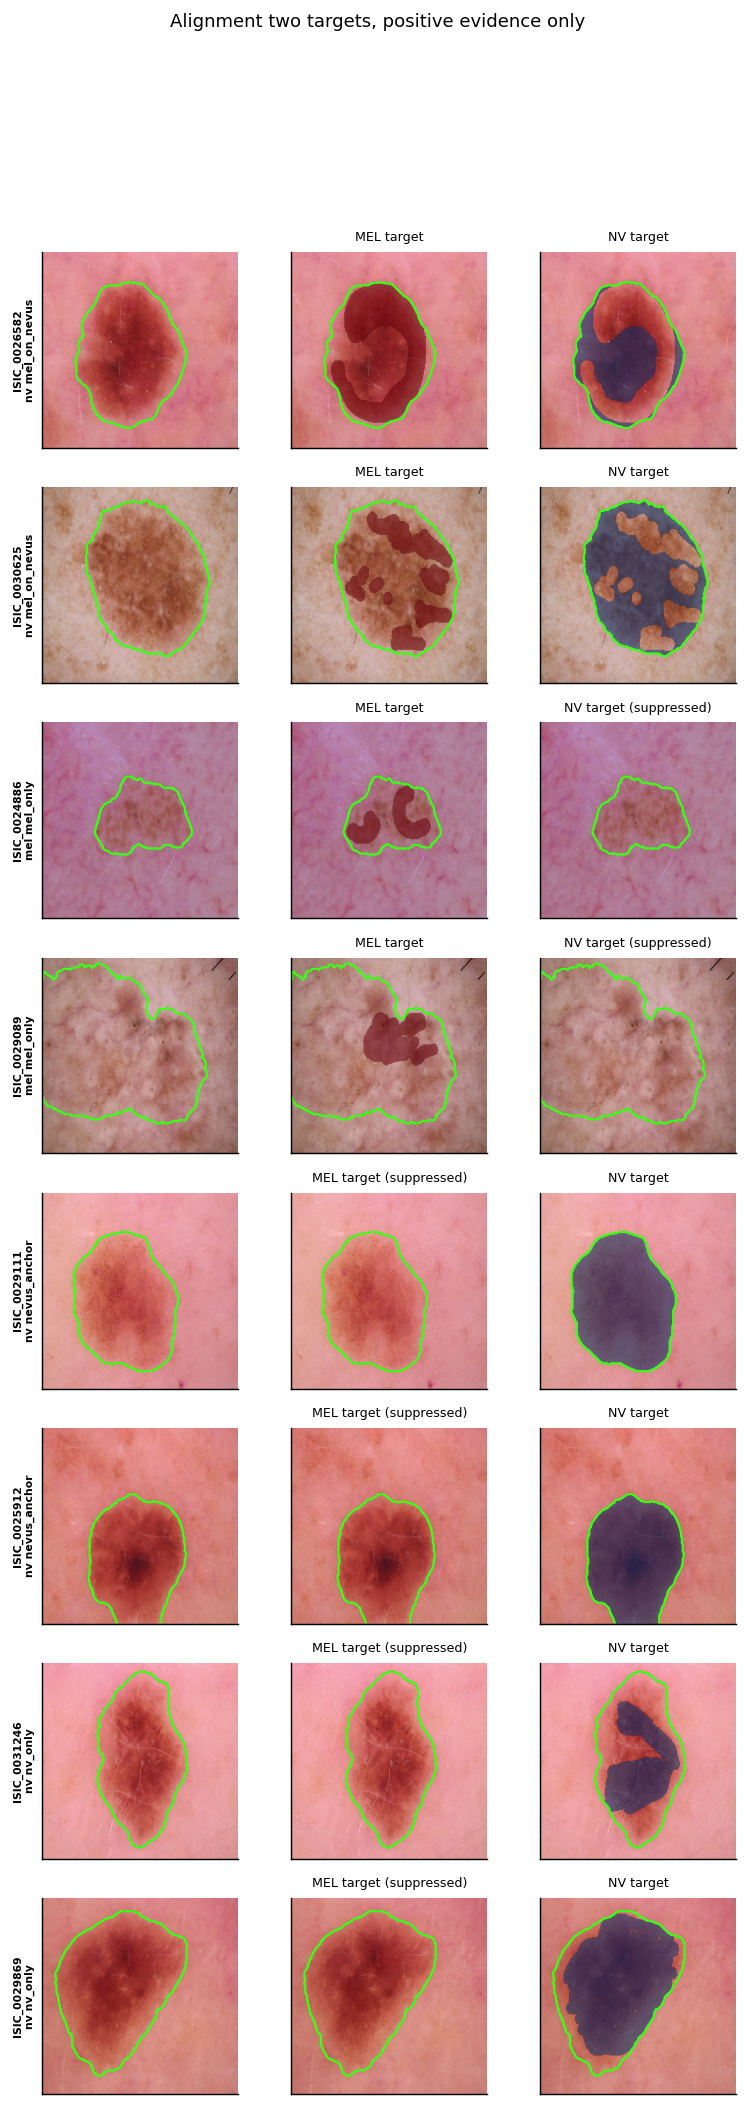

In [43]:
SHOW = pd.concat([g.sample(min(2, len(g)), random_state=0)
                  for _, g in FEAT.groupby("rule")], ignore_index=True)
fig, ax = plt.subplots(len(SHOW), 3, figsize=(7, 2.3 * len(SHOW)))
ax = np.atleast_2d(ax)
for i, (_, r) in enumerate(SHOW.iterrows()):
    rgb = transform_rgb(np.array(Image.open(
        (HAM_ROOT / r.image_rel_path).resolve()).convert("RGB")), GEOMETRY)
    L = transform_mask(np.array(Image.open(
        (HAM_ROOT / r.mask_rel_path).resolve()).convert("L")) > 127, GEOMETRY)[0]
    ax[i, 0].imshow(rgb)
    ax[i, 0].contour(L.astype(float), [0.5], colors="#39FF14", linewidths=1.2)
    ax[i, 0].set_ylabel(f"{r.image_id}\n{r.dx} {r.rule}",
                        fontsize=6, fontweight="bold")
    for j, (k, c, t) in enumerate([("feat_mel_rel_path", "Reds", "MEL"),
                                   ("feat_nv_rel_path", "Blues", "NV")]):
        m = transform_mask(np.array(Image.open(
            (HAM_ROOT / r[k]).resolve()).convert("L")) > 127, GEOMETRY)[0]
        ax[i, j + 1].imshow(rgb)
        if m.sum() > 0:
            ax[i, j + 1].imshow(np.where(m > 0.5, 1.0, np.nan), cmap=c,
                                alpha=0.55, vmin=0, vmax=1)
        ax[i, j + 1].contour(L.astype(float), [0.5], colors="#39FF14",
                             linewidths=1.2)
        ax[i, j + 1].set_title(f"{t} target"
                               f"{' (suppressed)' if m.sum() == 0 else ''}",
                               fontsize=7)
    for a in ax[i]:
        a.set_xticks([]); a.set_yticks([])
fig.suptitle("Alignment two targets, positive evidence only", fontsize=10)
fig.savefig(REPO / "results" / "alignment2" / "targets_sanity.png",
            dpi=140, bbox_inches="tight")
plt.show()

In [44]:
from scipy.ndimage import distance_transform_edt
from scipy.stats import spearmanr

rows_d = []
for _, r in FEAT.iterrows():
    L = to_grid(np.array(Image.open(
        (HAM_ROOT / r.mask_rel_path).resolve()).convert("L")) > 127)
    if L.sum() < 8:
        continue
    d = distance_transform_edt(L)[L]
    for ch, k in [("mel", "feat_mel_rel_path"), ("nv", "feat_nv_rel_path")]:
        t = to_grid(np.array(Image.open(
            (HAM_ROOT / r[k]).resolve()).convert("L")) > 127)[L]
        if t.sum() == 0 or t.all():
            continue
        rows_d.append({"rule": r.rule, "ch": ch,
                       "depth": float(spearmanr(t.astype(float), d).statistic)})
D = pd.DataFrame(rows_d)
print("target depth, positive prefers the core, negative prefers the rim")
print(D.groupby(["rule", "ch"]).depth.agg(["count", "median"]).round(3).to_string())

target depth, positive prefers the core, negative prefers the rim
                  count  median
rule         ch                
mel_on_nevus mel     10   0.214
             nv      10  -0.112
mel_only     mel     16   0.220
nv_only      nv       6   0.386
